In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import pandas as pd
from pandas.io.parsers.readers import STR_NA_VALUES

In [2]:
import warnings
warnings.filterwarnings('ignore') # Keeps the output clean for the teacher

In [3]:
custom_na_values = STR_NA_VALUES - {'None'}

In [4]:
# Load the dataset
df = pd.read_csv(
    '../data/synthetic_coffee_health_10000.csv', 
    keep_default_na=False, 
    na_values=custom_na_values
)

# Preview the first few rows
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,None,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,None,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [5]:
# Adjusting binary columns
df['Smoking'] = df['Smoking'].replace({0: 'No', 1: 'Yes'})
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].replace({0: 'No', 1: 'Yes'})

# Fix for Sorting (Sets the exact order for plots)
sleep_order = ['Poor', 'Fair', 'Good', 'Excellent']
df['Sleep_Quality'] = pd.Categorical(df['Sleep_Quality'], categories=sleep_order, ordered=True)

# 2. Ordinal Encoding (Creating numerical versions for the heatmap)
df['Sleep_Quality_Num'] = df['Sleep_Quality'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}).astype(float)
df['Stress_Level_Num'] = df['Stress_Level'].map({'Low': 0, 'Medium': 1, 'High': 2}).astype(float)
df['Health_Issues_Num'] = df['Health_Issues'].map({'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}).astype(float)

# Preview the first few rows
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption,Sleep_Quality_Num,Stress_Level_Num,Health_Issues_Num
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,None,Other,No,No,2.0,0.0,0.0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,None,Service,No,No,2.0,0.0,0.0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,No,No,1.0,1.0,1.0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,No,No,2.0,0.0,1.0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,No,Yes,1.0,1.0,1.0


In [6]:
print("--- MISSING VALUE INVENTORY ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])
print("\nTotal Missing Cells:", df.isnull().sum().sum())

--- MISSING VALUE INVENTORY ---
Series([], dtype: int64)

Total Missing Cells: 0


In [7]:
print("\n--- GLOBAL DISTRIBUTIONS (Numerical) ---")
display(df.describe().T)


--- GLOBAL DISTRIBUTIONS (Numerical) ---


,count,mean,std,min,25%,50%,75%,max
ID,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.250,10000.0
Age,10000.0,34.94910,11.160939,18.0,26.00,34.0,43.000,80.0
Coffee_Intake,10000.0,2.50923,1.450248,0.0,1.50,2.5,3.500,8.2
Caffeine_mg,10000.0,238.41101,137.748815,0.0,138.75,235.4,332.025,780.3
Sleep_Hours,10000.0,6.63622,1.222055,3.0,5.80,6.6,7.500,10.0
BMI,10000.0,23.98686,3.906411,15.0,21.30,24.0,26.600,38.2
Heart_Rate,10000.0,70.61780,9.822951,50.0,64.00,71.0,77.000,109.0
Physical_Activity_Hours,10000.0,7.48704,4.315180,0.0,3.70,7.5,11.200,15.0
Sleep_Quality_Num,10000.0,1.73800,0.809952,0.0,1.00,2.0,2.000,3.0
Stress_Level_Num,10000.0,0.39720,0.657020,0.0,0.00,0.0,1.000,2.0


In [8]:
print("\n--- GLOBAL DISTRIBUTIONS (Categorical) ---")
display(df.describe(include=['object']).T)


--- GLOBAL DISTRIBUTIONS (Categorical) ---


,count,unique,top,freq
Gender,10000,3,Female,5001
Country,10000,20,Canada,543
Stress_Level,10000,3,Low,6989
Health_Issues,10000,4,None,5941
Occupation,10000,5,Office,2073
Smoking,10000,2,No,7996
Alcohol_Consumption,10000,2,No,6993


In [9]:
print("--- UNIQUE CATEGORIES IN THE DATASET ---")
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    unique_values = df[col].unique()
    print(f"{col}: {unique_values}")

--- UNIQUE CATEGORIES IN THE DATASET ---
Gender: ['Male' 'Female' 'Other']
Country: ['Germany' 'Brazil' 'Spain' 'Mexico' 'France' 'Canada' 'UK' 'Switzerland'
 'Netherlands' 'Italy' 'China' 'Japan' 'Belgium' 'Finland' 'Australia'
 'USA' 'Sweden' 'India' 'Norway' 'South Korea']
Stress_Level: ['Low' 'Medium' 'High']
Health_Issues: ['None' 'Mild' 'Moderate' 'Severe']
Occupation: ['Other' 'Service' 'Office' 'Student' 'Healthcare']
Smoking: ['No' 'Yes']
Alcohol_Consumption: ['No' 'Yes']


## 3. Exploratory Data Analysis (EDA): Visualizations

With the data cleaned and our targets defined, this section explores the distributions, correlations, and deeper relationships within the dataset. Our visual analysis follows a structured approach:
1.  **Global Distributions:** Understanding the demographics, habits, and baseline health metrics of our sample.
2.  **Correlation Analysis:** Identifying linear relationships between numerical variables.
3.  **Caffeine Impact Analysis:** A deep-dive into how varying levels of caffeine consumption interact with lifestyle groups, sleep quality, and physiological stress.

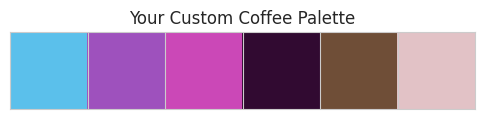

In [10]:
# 1. Define a custom list of hex codes (The "Coffee Palette")
custom_palette = [
    "#5BC0EB",
    '#9E51BD',
    '#CB48B7',
    '#310A31',
    '#6F4E37',
    '#E2C2C6'
]

# Define the specific colors
espresso_color = '#2A1A10'
coffee_color = '#6F4E37' 
latte_color = '#E2C2C6'  
milky_color = '#FFF0E5'

gradient = LinearSegmentedColormap.from_list("latte_to_coffee", [milky_color, latte_color, coffee_color, espresso_color])

# 2. Set this as the global default for all Seaborn plots
sns.set_palette(custom_palette)
sns.set_style("whitegrid") # Clean white background

# 3. Quick test to see your new colors
sns.palplot(custom_palette)
plt.title("Your Custom Coffee Palette")
plt.show()

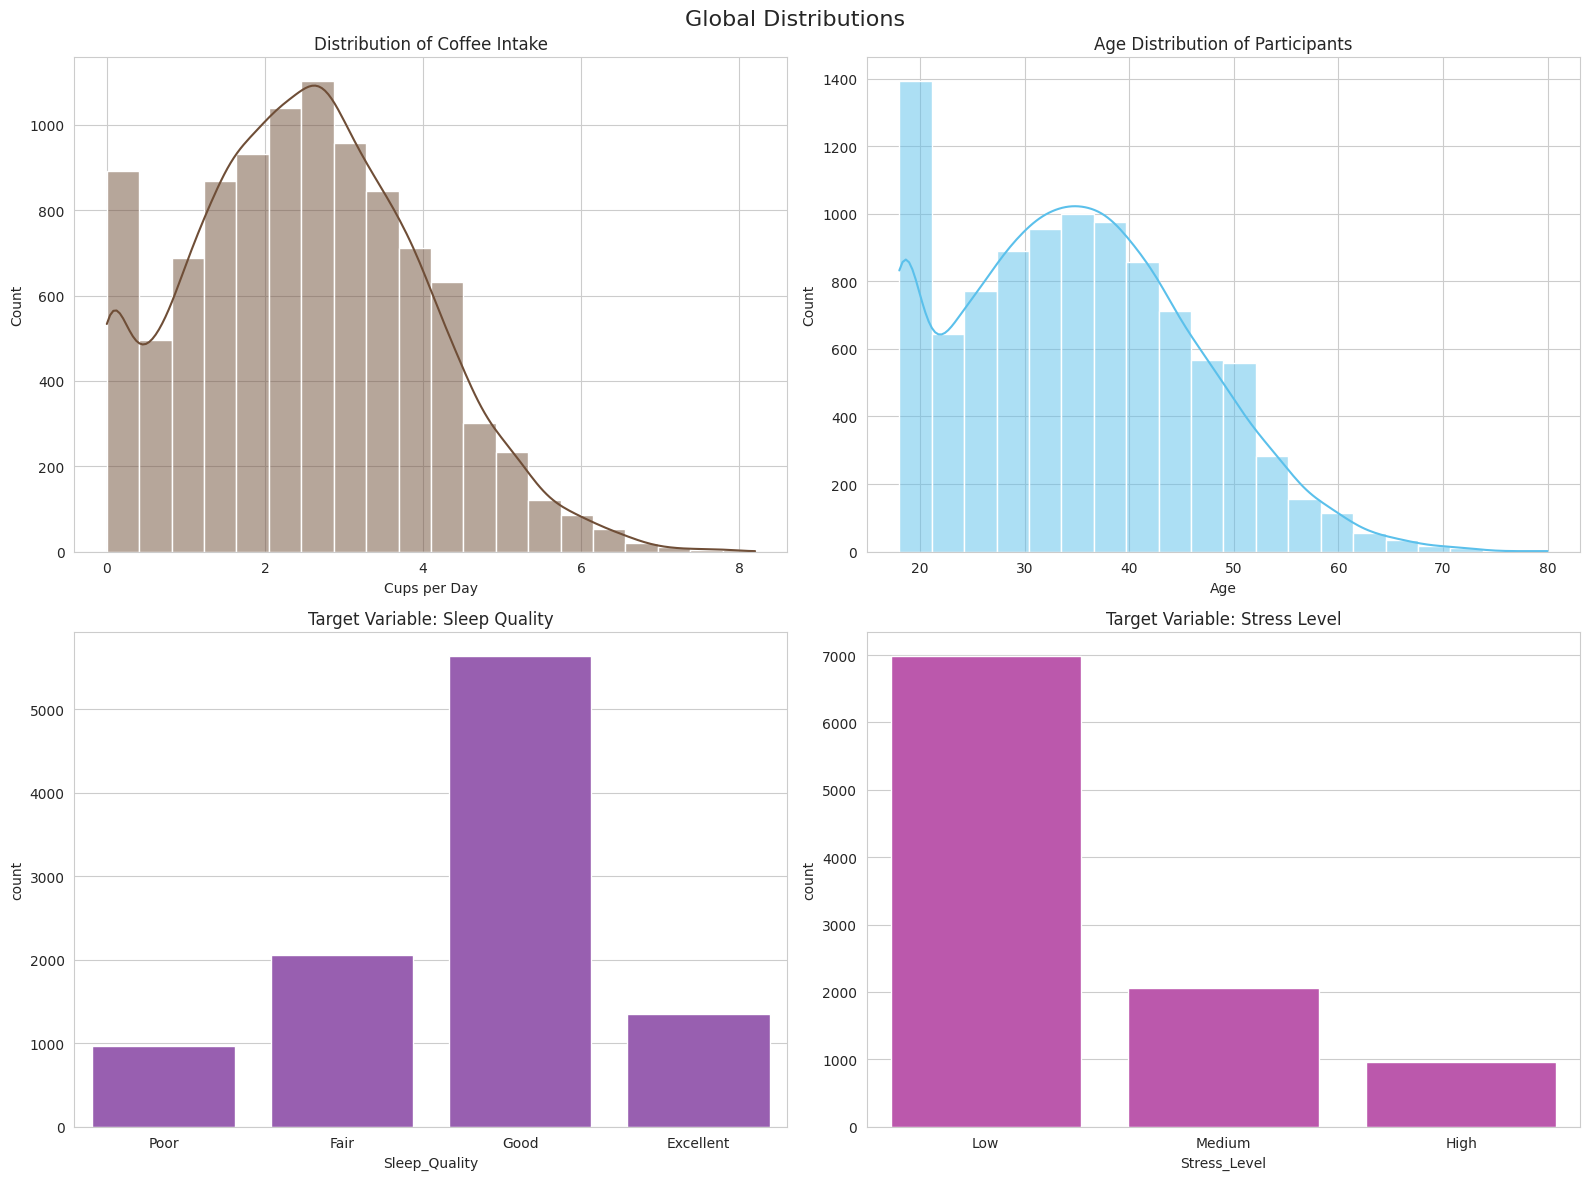

In [11]:
# Cell 9: Basic Visualizations using Custom Palette
# Create a summary dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Global Distributions', fontsize=16)

# 1. Coffee Intake Distribution (Numerical)
# Using the 5th color (Coffee Brown) for coffee data
sns.histplot(df['Coffee_Intake'], bins=20, kde=True, ax=axes[0, 0], color=custom_palette[4])
axes[0, 0].set_title('Distribution of Coffee Intake')
axes[0, 0].set_xlabel('Cups per Day')

# 2. Age Distribution (Numerical)
# Using the 1st color (Blue) for demographics
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0, 1], color=custom_palette[0])
axes[0, 1].set_title('Age Distribution of Participants')

# 3. Sleep Quality (Target 1)
# Using the 2nd color (Purple)
sleep_order = ['Poor', 'Fair', 'Good', 'Excellent']
sns.countplot(data=df, x='Sleep_Quality', order=sleep_order, ax=axes[1, 0], color=custom_palette[1])
axes[1, 0].set_title('Target Variable: Sleep Quality')

# 4. Stress Levels (Target 2)
# Using the 3rd color (Pink/Magenta)
stress_order = ['Low', 'Medium', 'High']
sns.countplot(data=df, x='Stress_Level', order=stress_order, ax=axes[1, 1], color=custom_palette[2])
axes[1, 1].set_title('Target Variable: Stress Level')

plt.tight_layout()
plt.show()

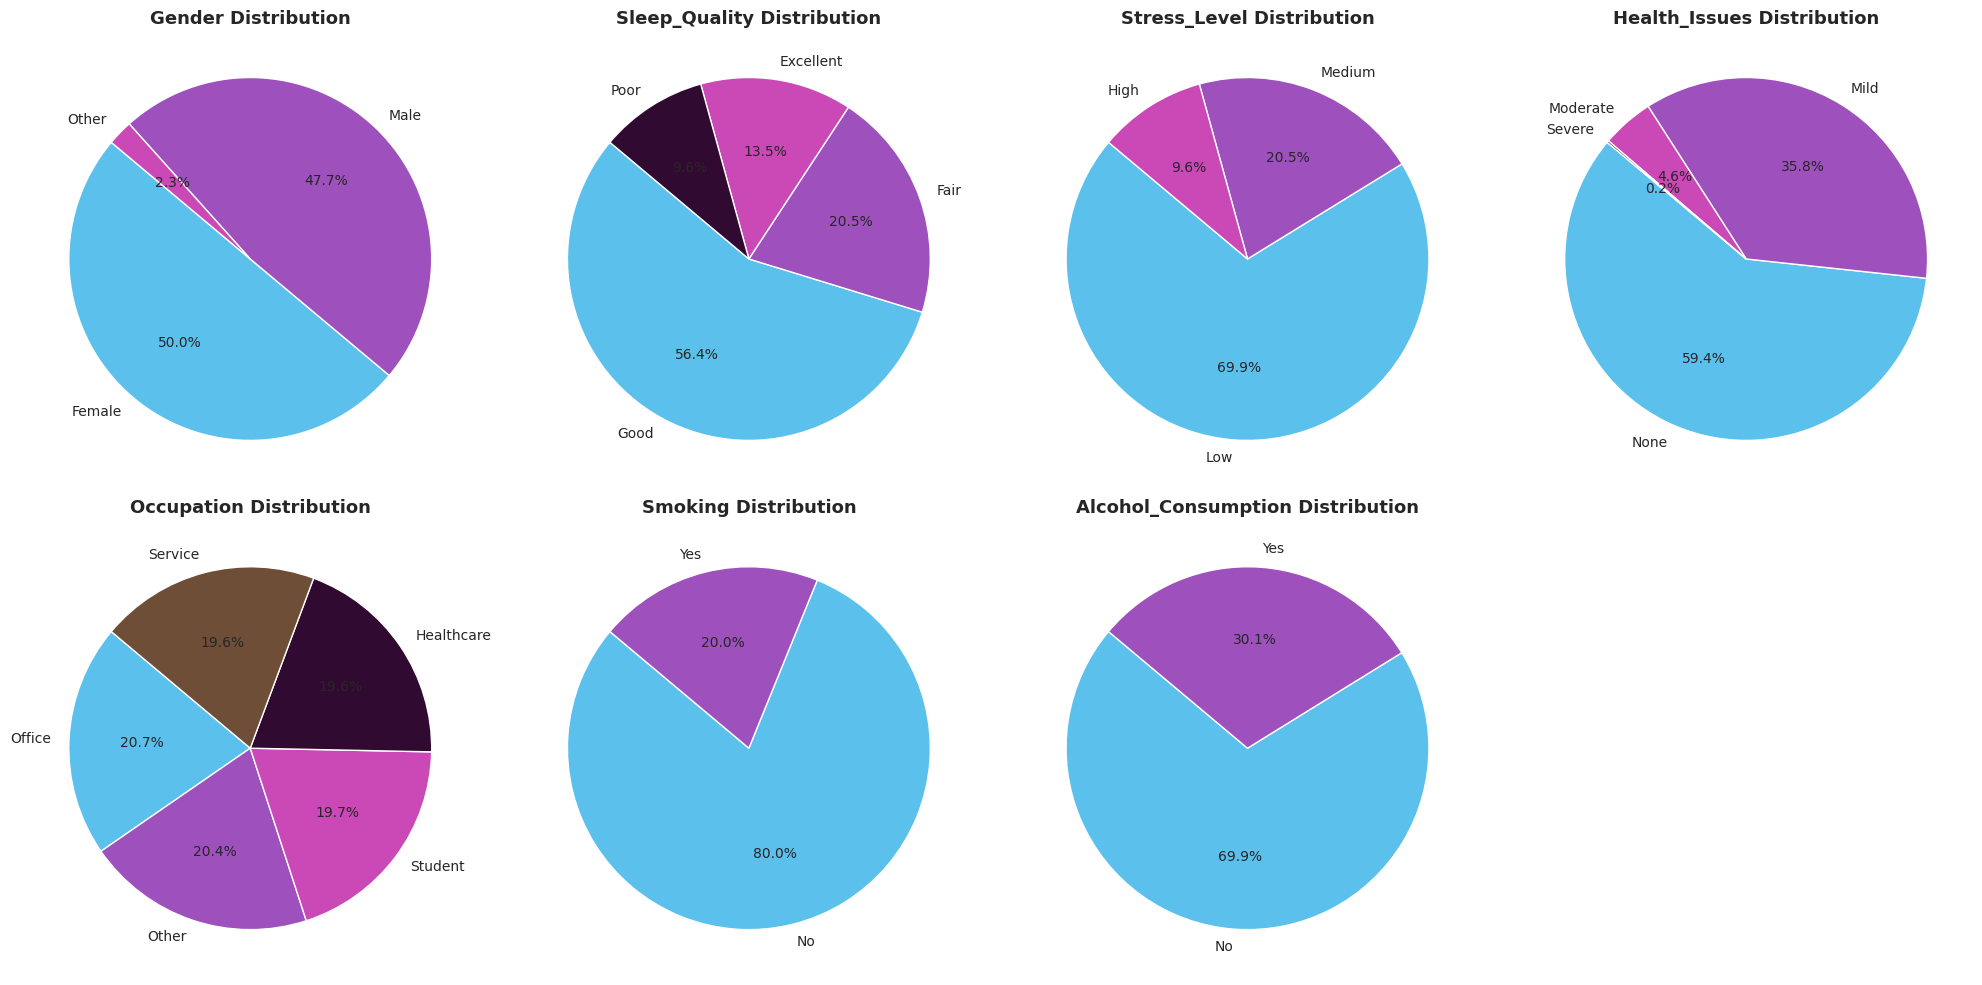

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

cat_cols = [
    'Gender', 'Sleep_Quality', 'Stress_Level', 'Health_Issues', 
    'Occupation', 'Smoking', 'Alcohol_Consumption'
]
continuous_vars = ['Age', 'BMI', 'Heart_Rate', 'Sleep_Hours']

for i, col in enumerate(cat_cols):
    ax = axes[i]
    counts = df[col].value_counts()
    
    # Create the pie chart
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=custom_palette)
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')

fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

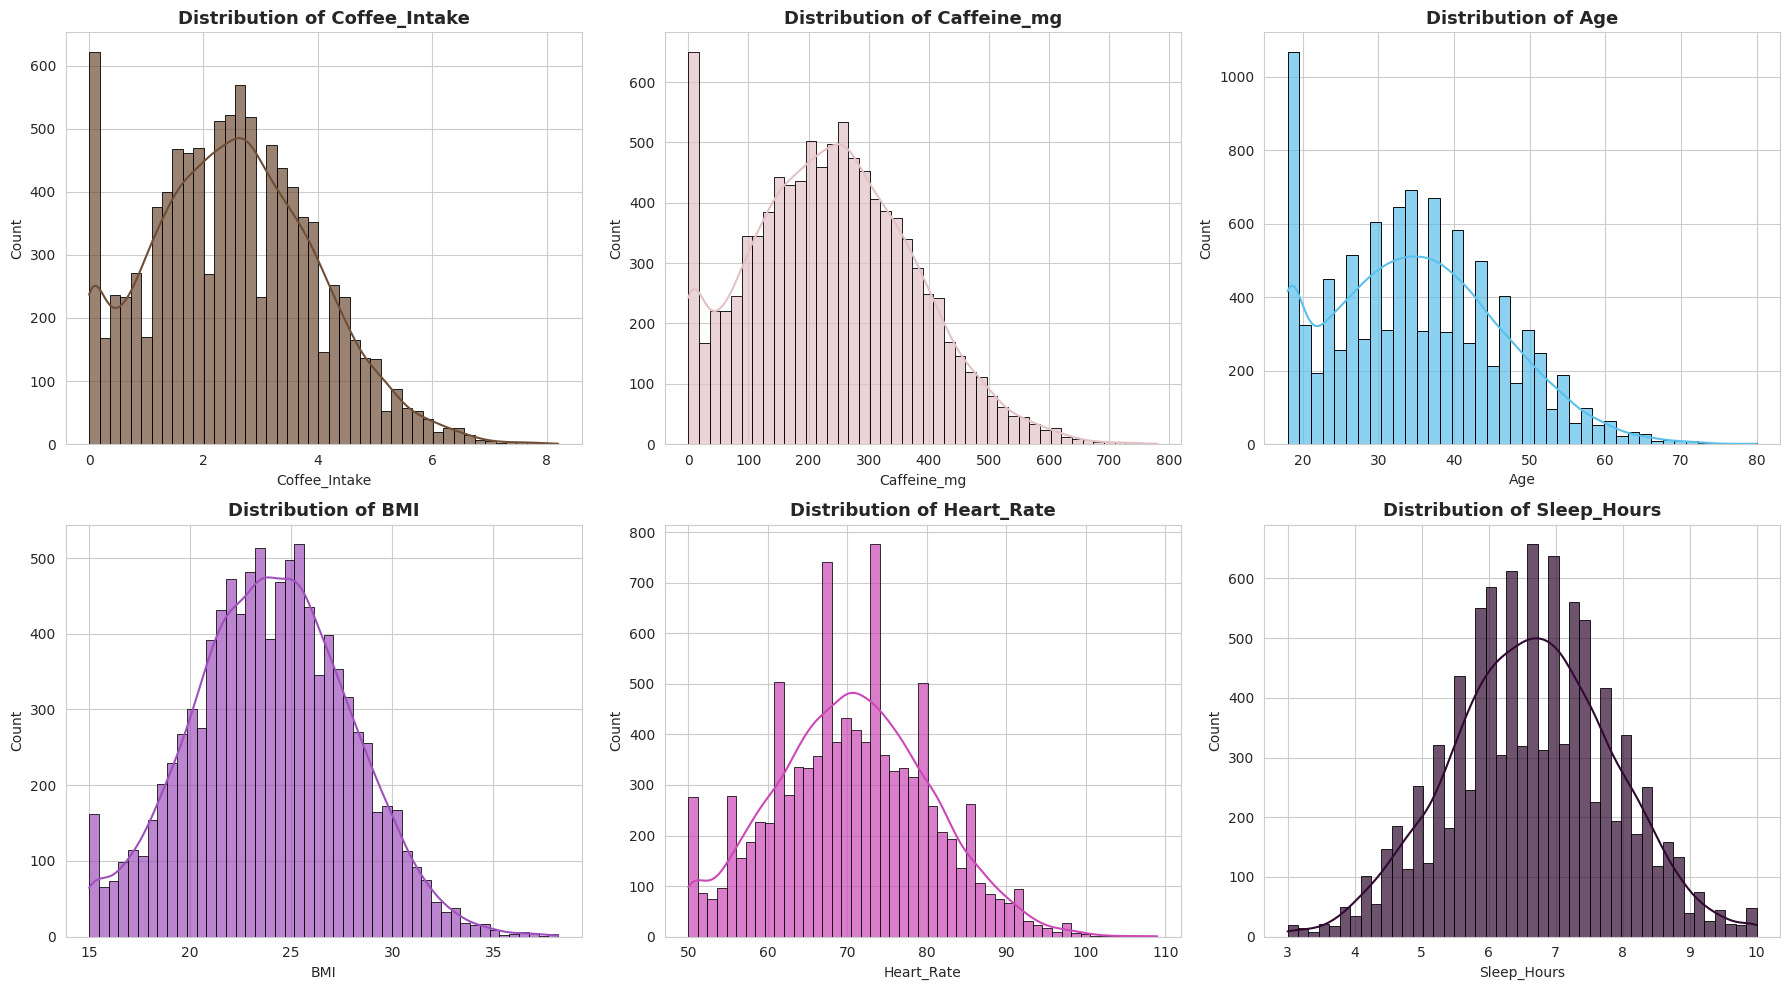

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# List of numerical columns
num_cols = ['Coffee_Intake', 'Caffeine_mg', 'Age', 'BMI', 'Heart_Rate', 'Sleep_Hours']

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    # 1. Special Colors for Coffee/Caffeine
    if col == 'Coffee_Intake':
        color = coffee_color
    elif col == 'Caffeine_mg':
        color = latte_color
    # 2. Cycle through custom palette for others
    else:
        color = custom_palette[i-2 % len(custom_palette)]
        
    sns.histplot(df[col], kde=True, ax=ax, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

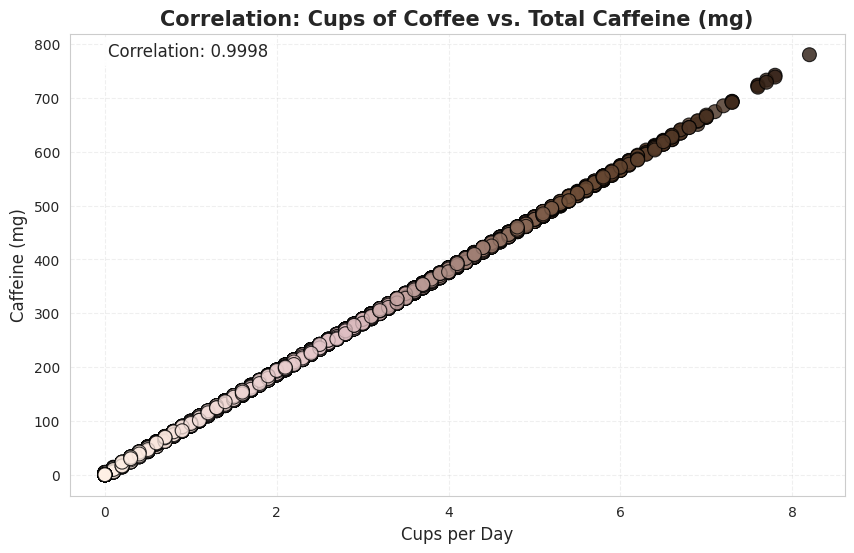

In [14]:
plt.figure(figsize=(10, 6))

# 2. The Scatter Plot
sns.scatterplot(
    data=df, 
    x='Coffee_Intake', 
    y='Caffeine_mg', 
    hue='Coffee_Intake', # The color changes based on how much coffee they drink
    palette=gradient, # Apply our custom gradient
    s=100,               # Size of dots
    alpha=0.8,           # Transparency
    edgecolor='black',   # Distinct edges
    legend=False         # We don't need a legend since the axis tells us the amount
)

plt.title('Correlation: Cups of Coffee vs. Total Caffeine (mg)', fontsize=15, fontweight='bold')
plt.xlabel('Cups per Day', fontsize=12)
plt.ylabel('Caffeine (mg)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# Calculate correlation text
corr = df['Coffee_Intake'].corr(df['Caffeine_mg'])
plt.text(0.05, 0.95, f'Correlation: {corr:.4f}', transform=plt.gca().transAxes, 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.9, boxstyle='round'))

plt.show()

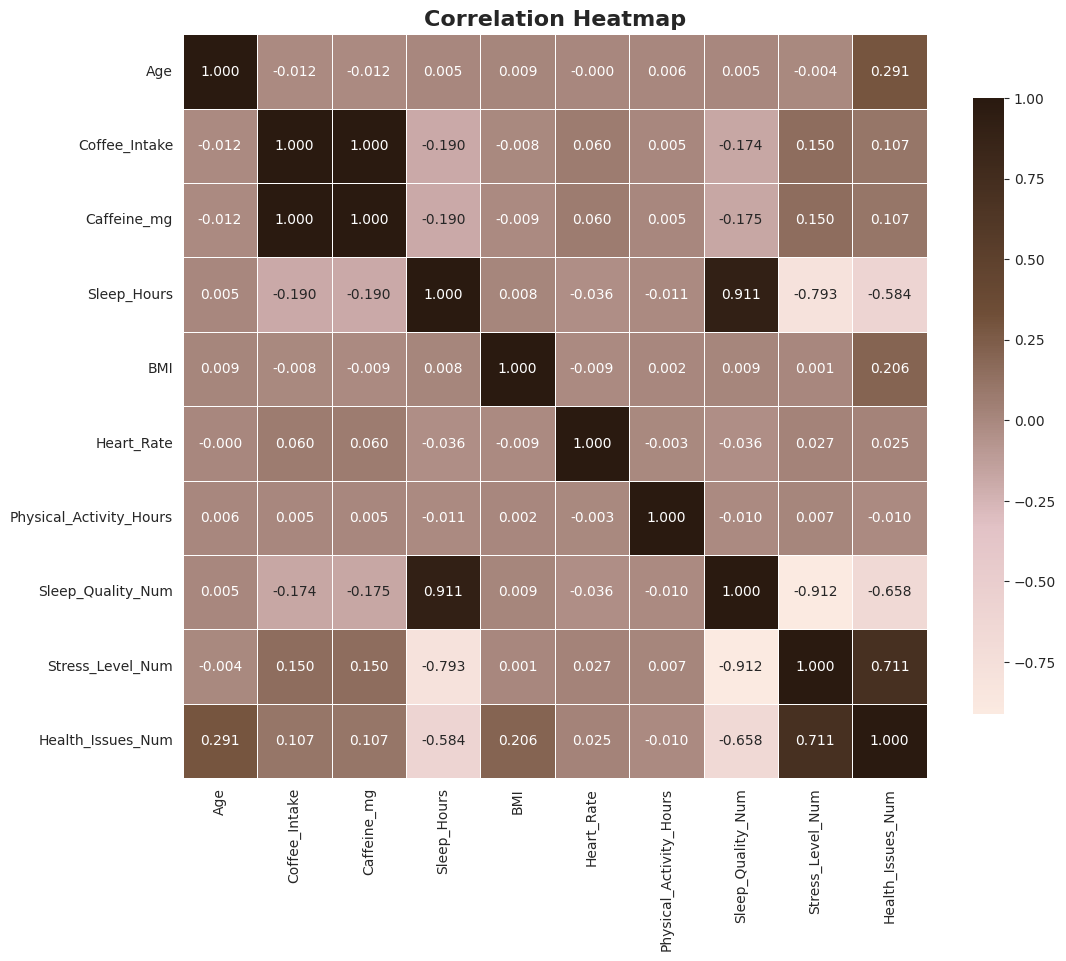

In [15]:
numeric_cols = df.select_dtypes(include=['number']).columns
# Exclude ID if present
if 'ID' in numeric_cols:
    numeric_cols = numeric_cols.drop('ID')
corr_matrix = df[numeric_cols].corr()

# 3. Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".3f", 
    cmap=gradient,  # <--- YOUR NEW GRADIENT
    center=0,          # Adjusts the center of the color map
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

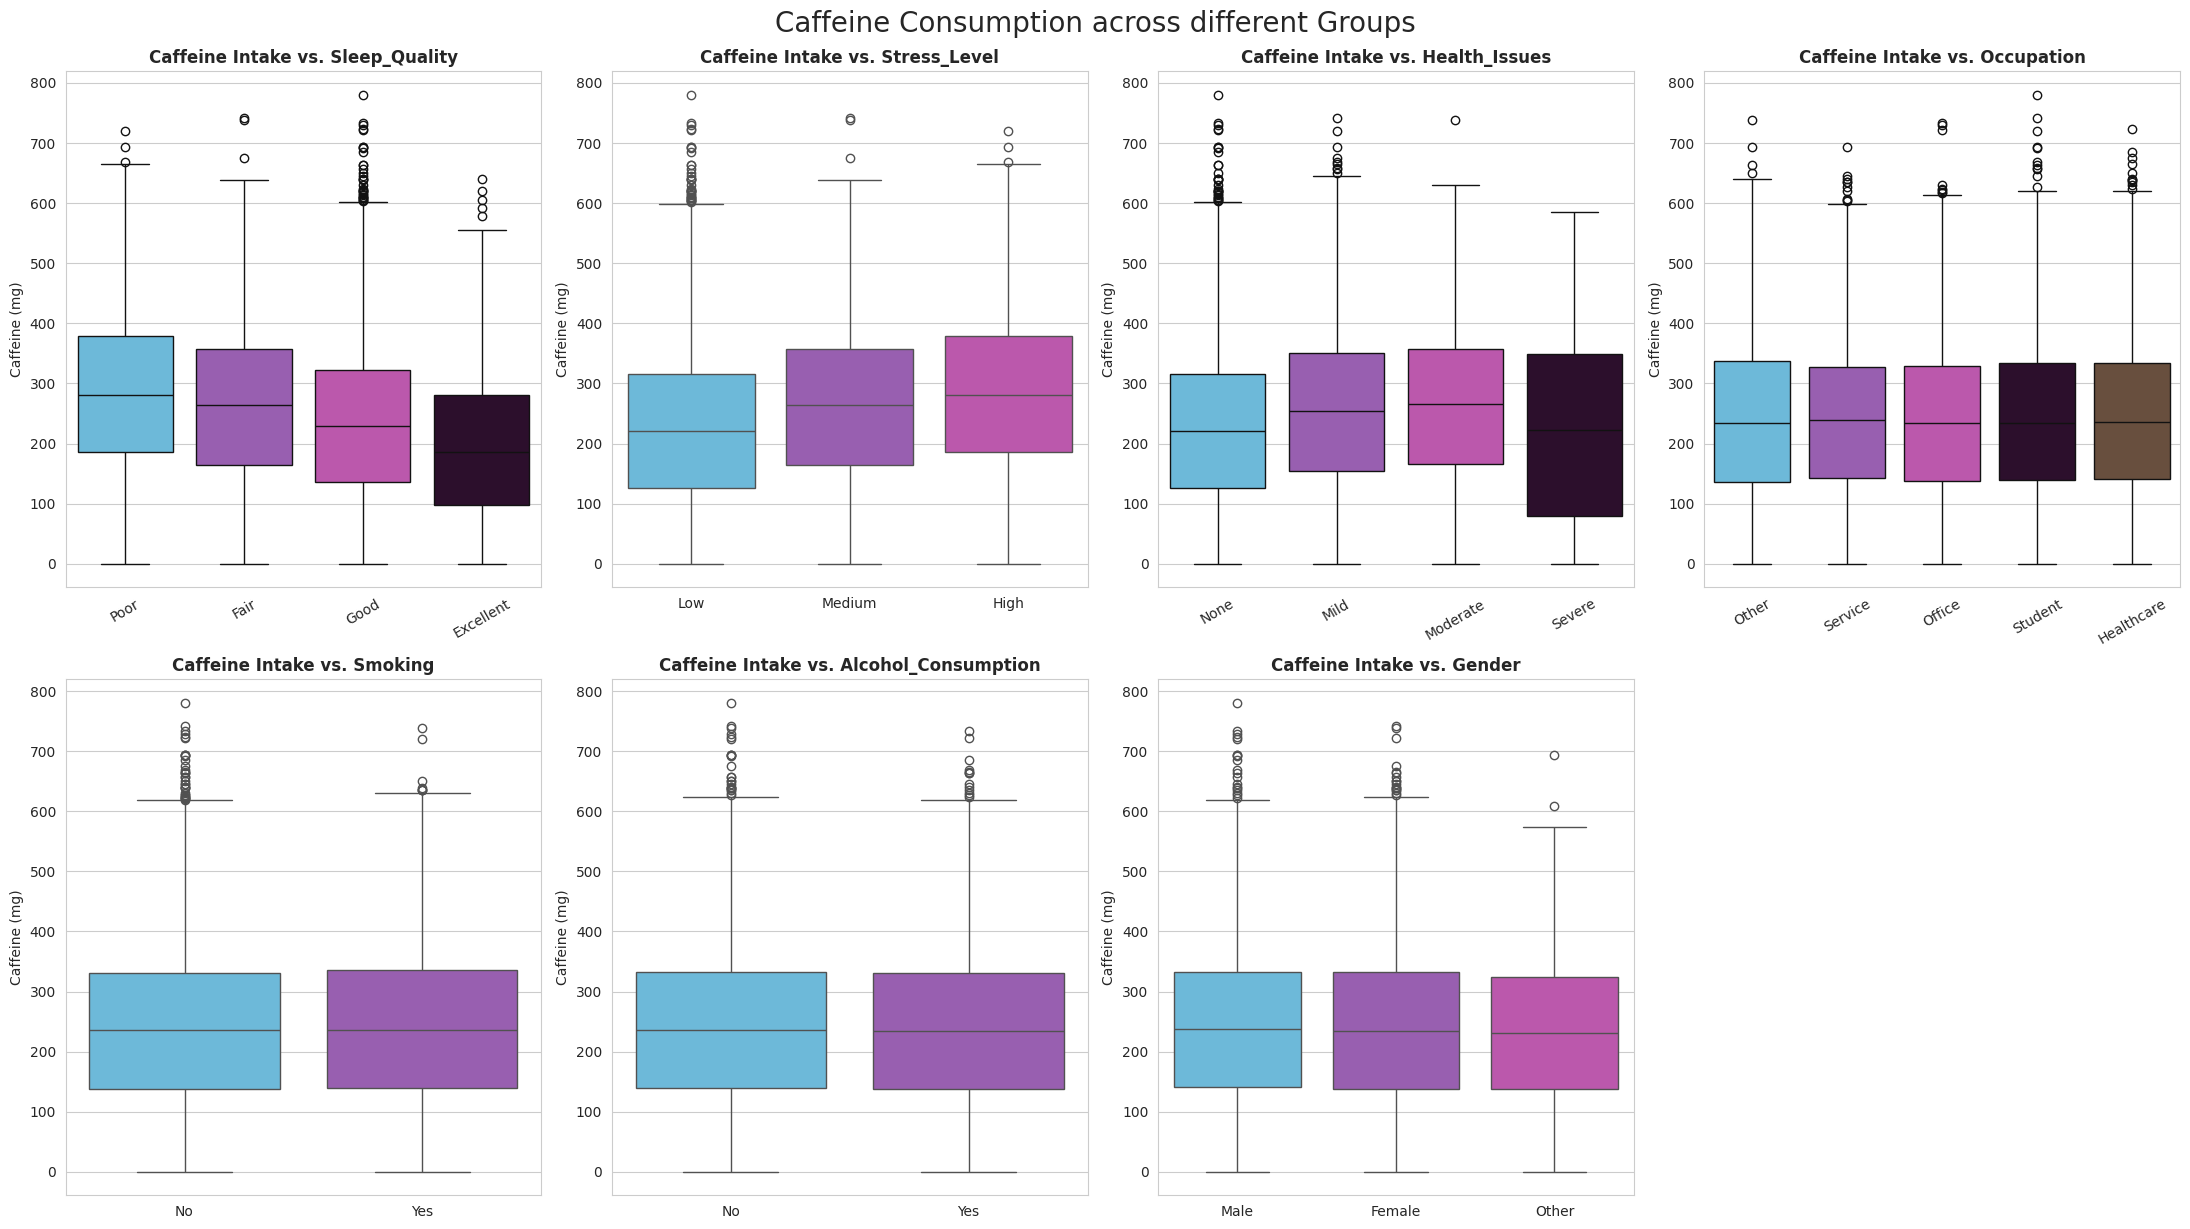

In [16]:
# List of categorical variables to check
cat_impact_cols = [
    'Sleep_Quality', 'Stress_Level', 'Health_Issues', 
    'Occupation', 'Smoking', 'Alcohol_Consumption', 'Gender'
]

rows = 2
cols = 4 # Fits 8 plots (we have 7)
fig, axes = plt.subplots(rows, cols, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(cat_impact_cols):
    ax = axes[i]
    
    # Create Box Plot
    sns.boxplot(
        data=df, 
        x=col, 
        y='Caffeine_mg', 
        ax=ax, 
        palette=custom_palette # Uses your project palette
    )
    
    ax.set_title(f'Caffeine Intake vs. {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Caffeine (mg)')
    
    # Rotate labels if needed (like Occupation)
    if df[col].nunique() > 3:
        ax.tick_params(axis='x', rotation=30)

# Hide empty subplots
for j in range(len(cat_impact_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Caffeine Consumption across different Groups', fontsize=20, y=1.02)
plt.show()

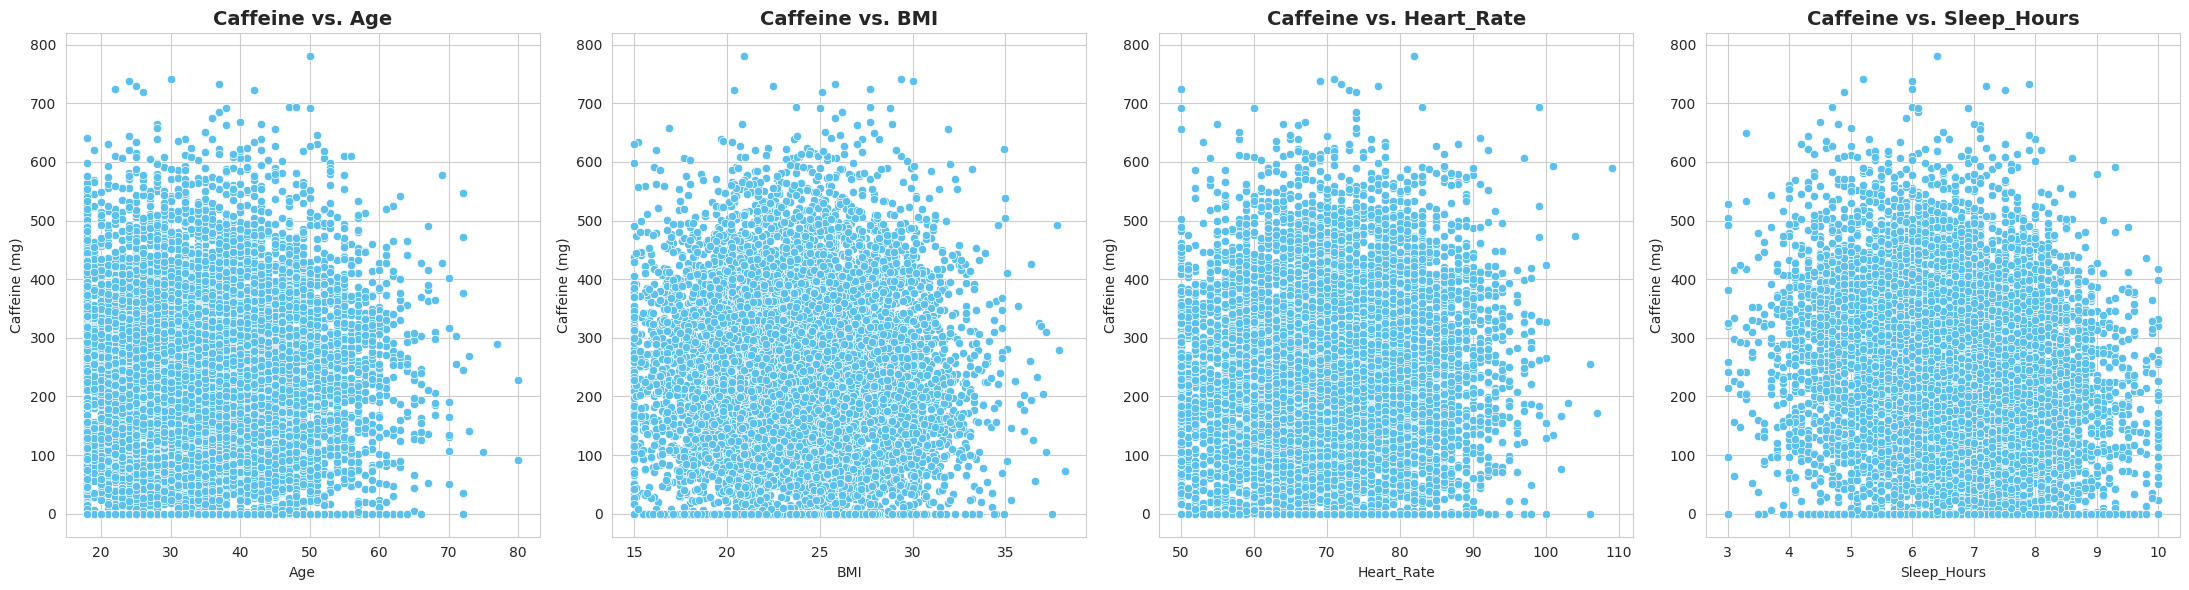

In [ ]:
# List of numerical variables
num_impact_cols = ['Age', 'BMI', 'Heart_Rate', 'Sleep_Hours']

# Setup grid (1 row is enough for 4 plots)
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
axes = axes.flatten()

for i, col in enumerate(num_impact_cols):
    ax = axes[i]
    
    # Create Scatter Plot with Trend Line
    sns.scatterplot(
        data=df, 
        x=col, 
        y='Caffeine_mg', 
        ax=ax
    )
    
    ax.set_title(f'Caffeine vs. {col}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Caffeine (mg)')

plt.tight_layout()
plt.show()

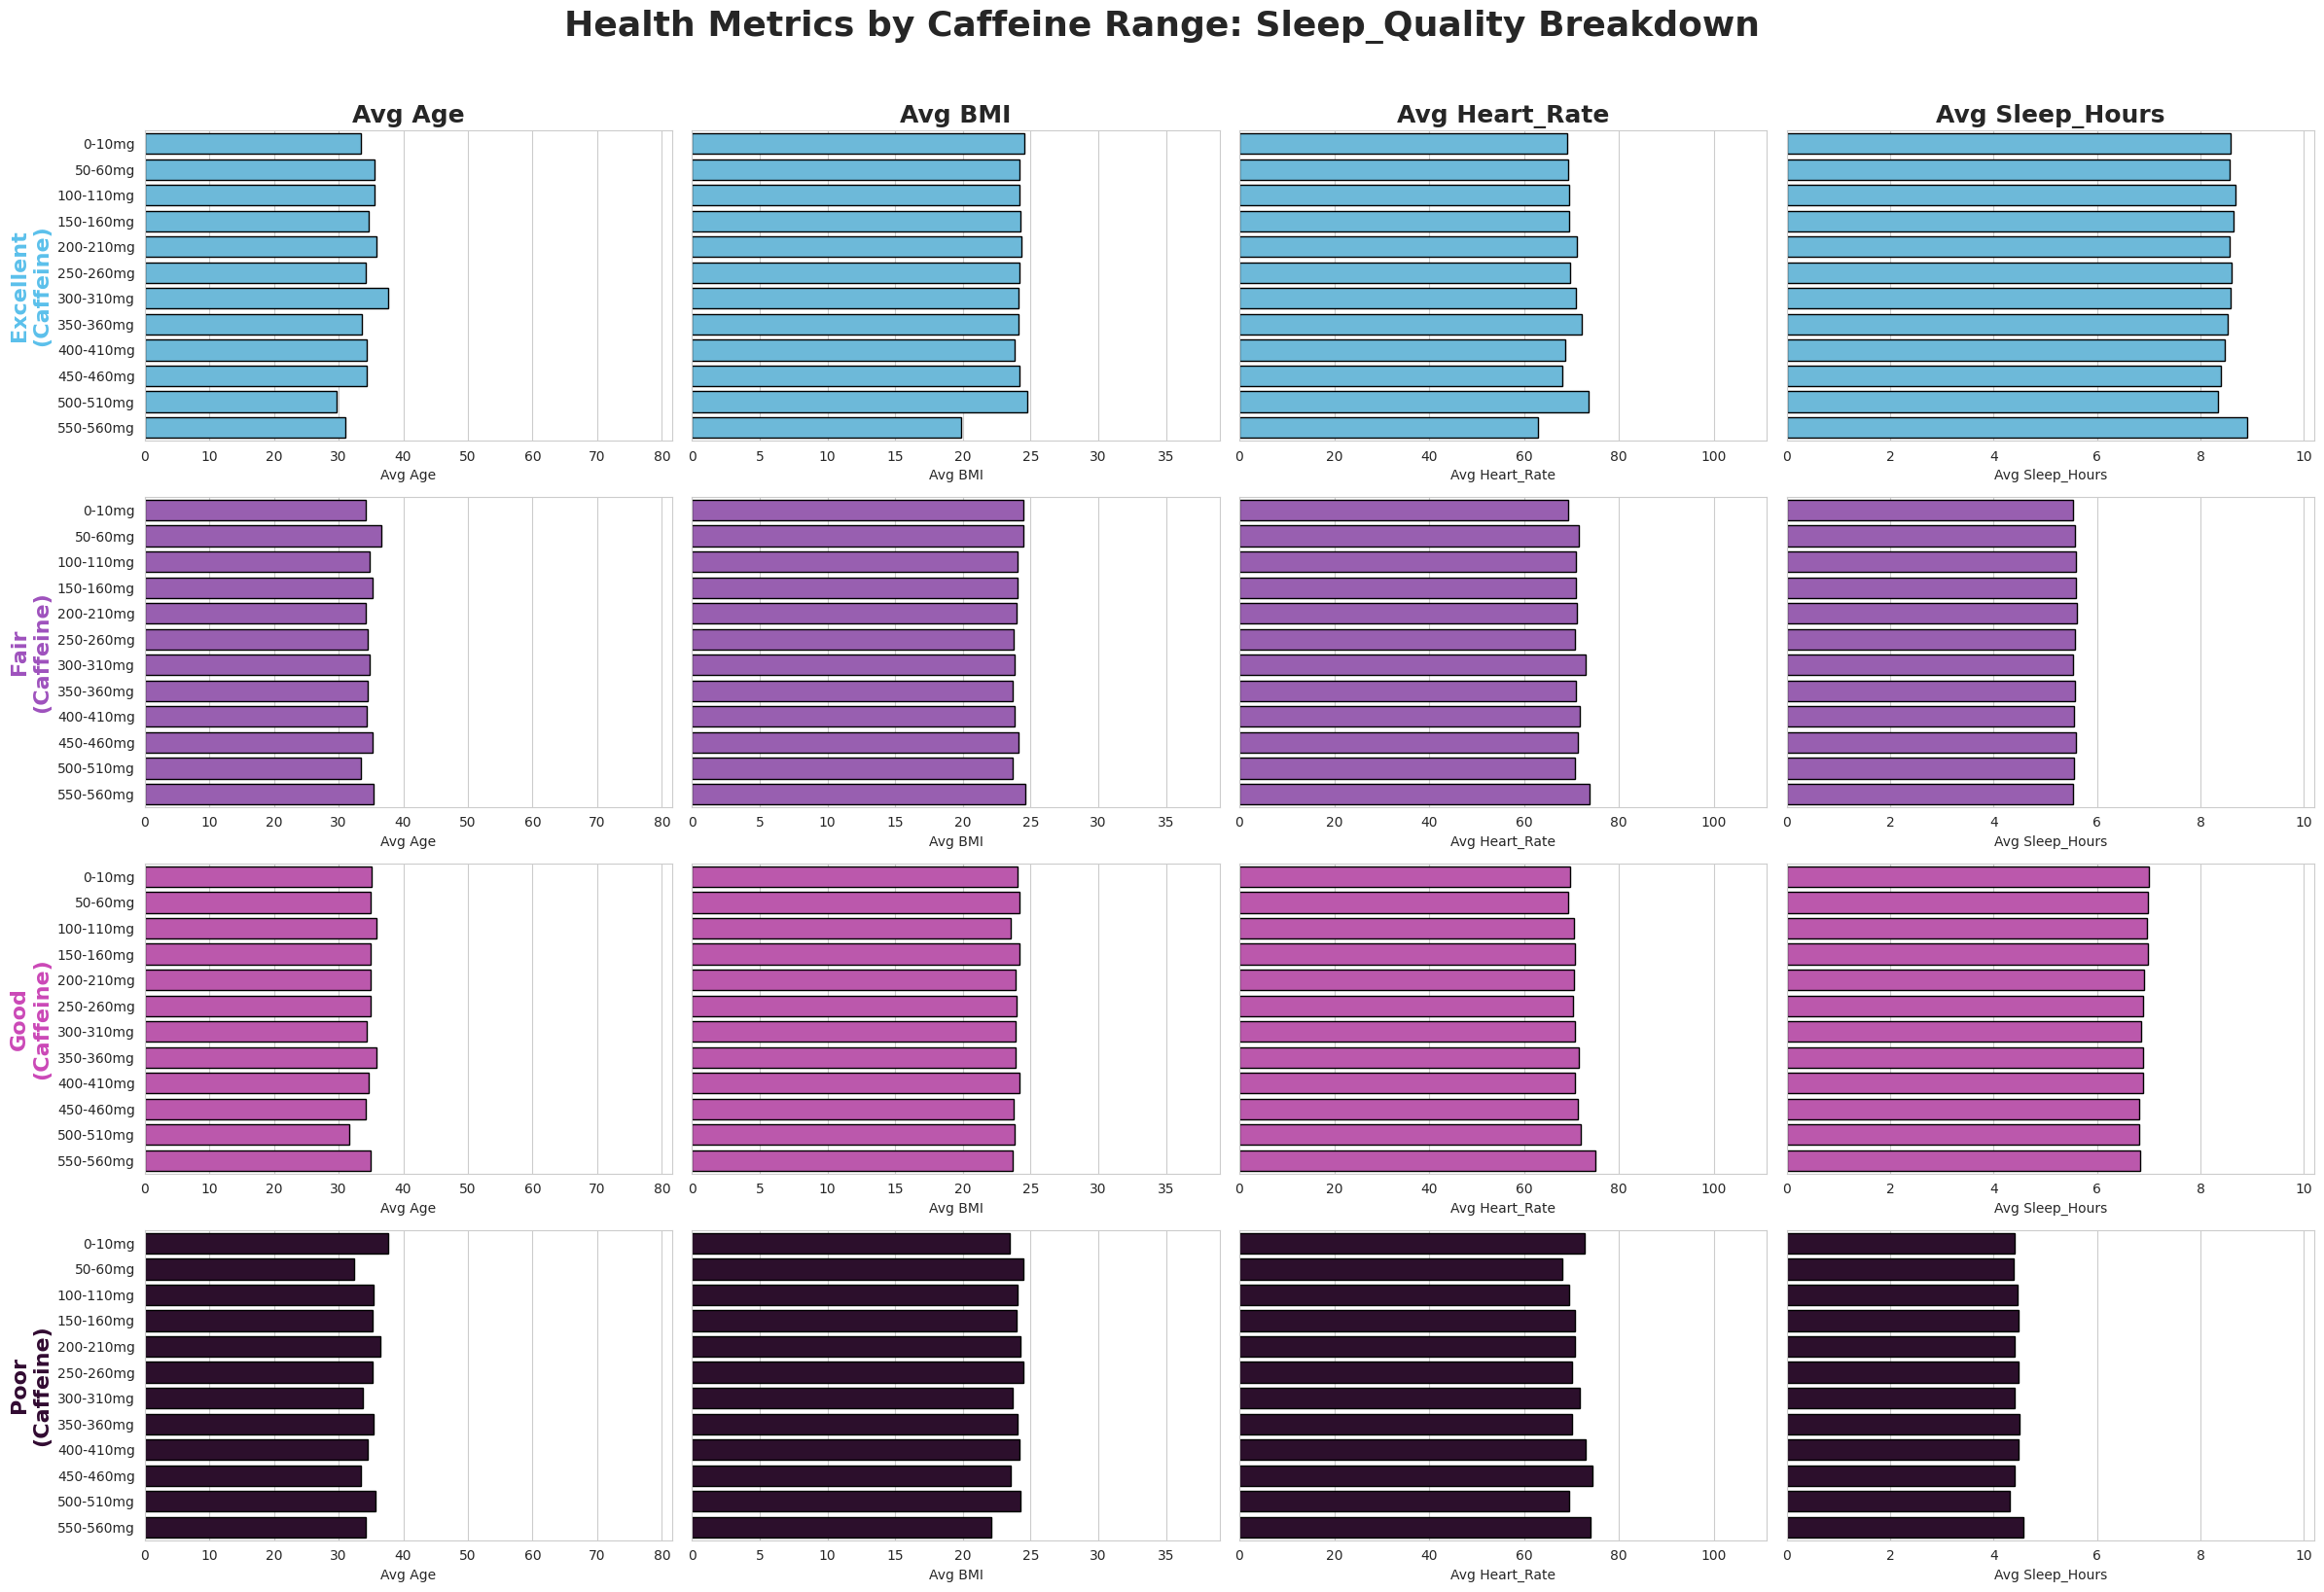

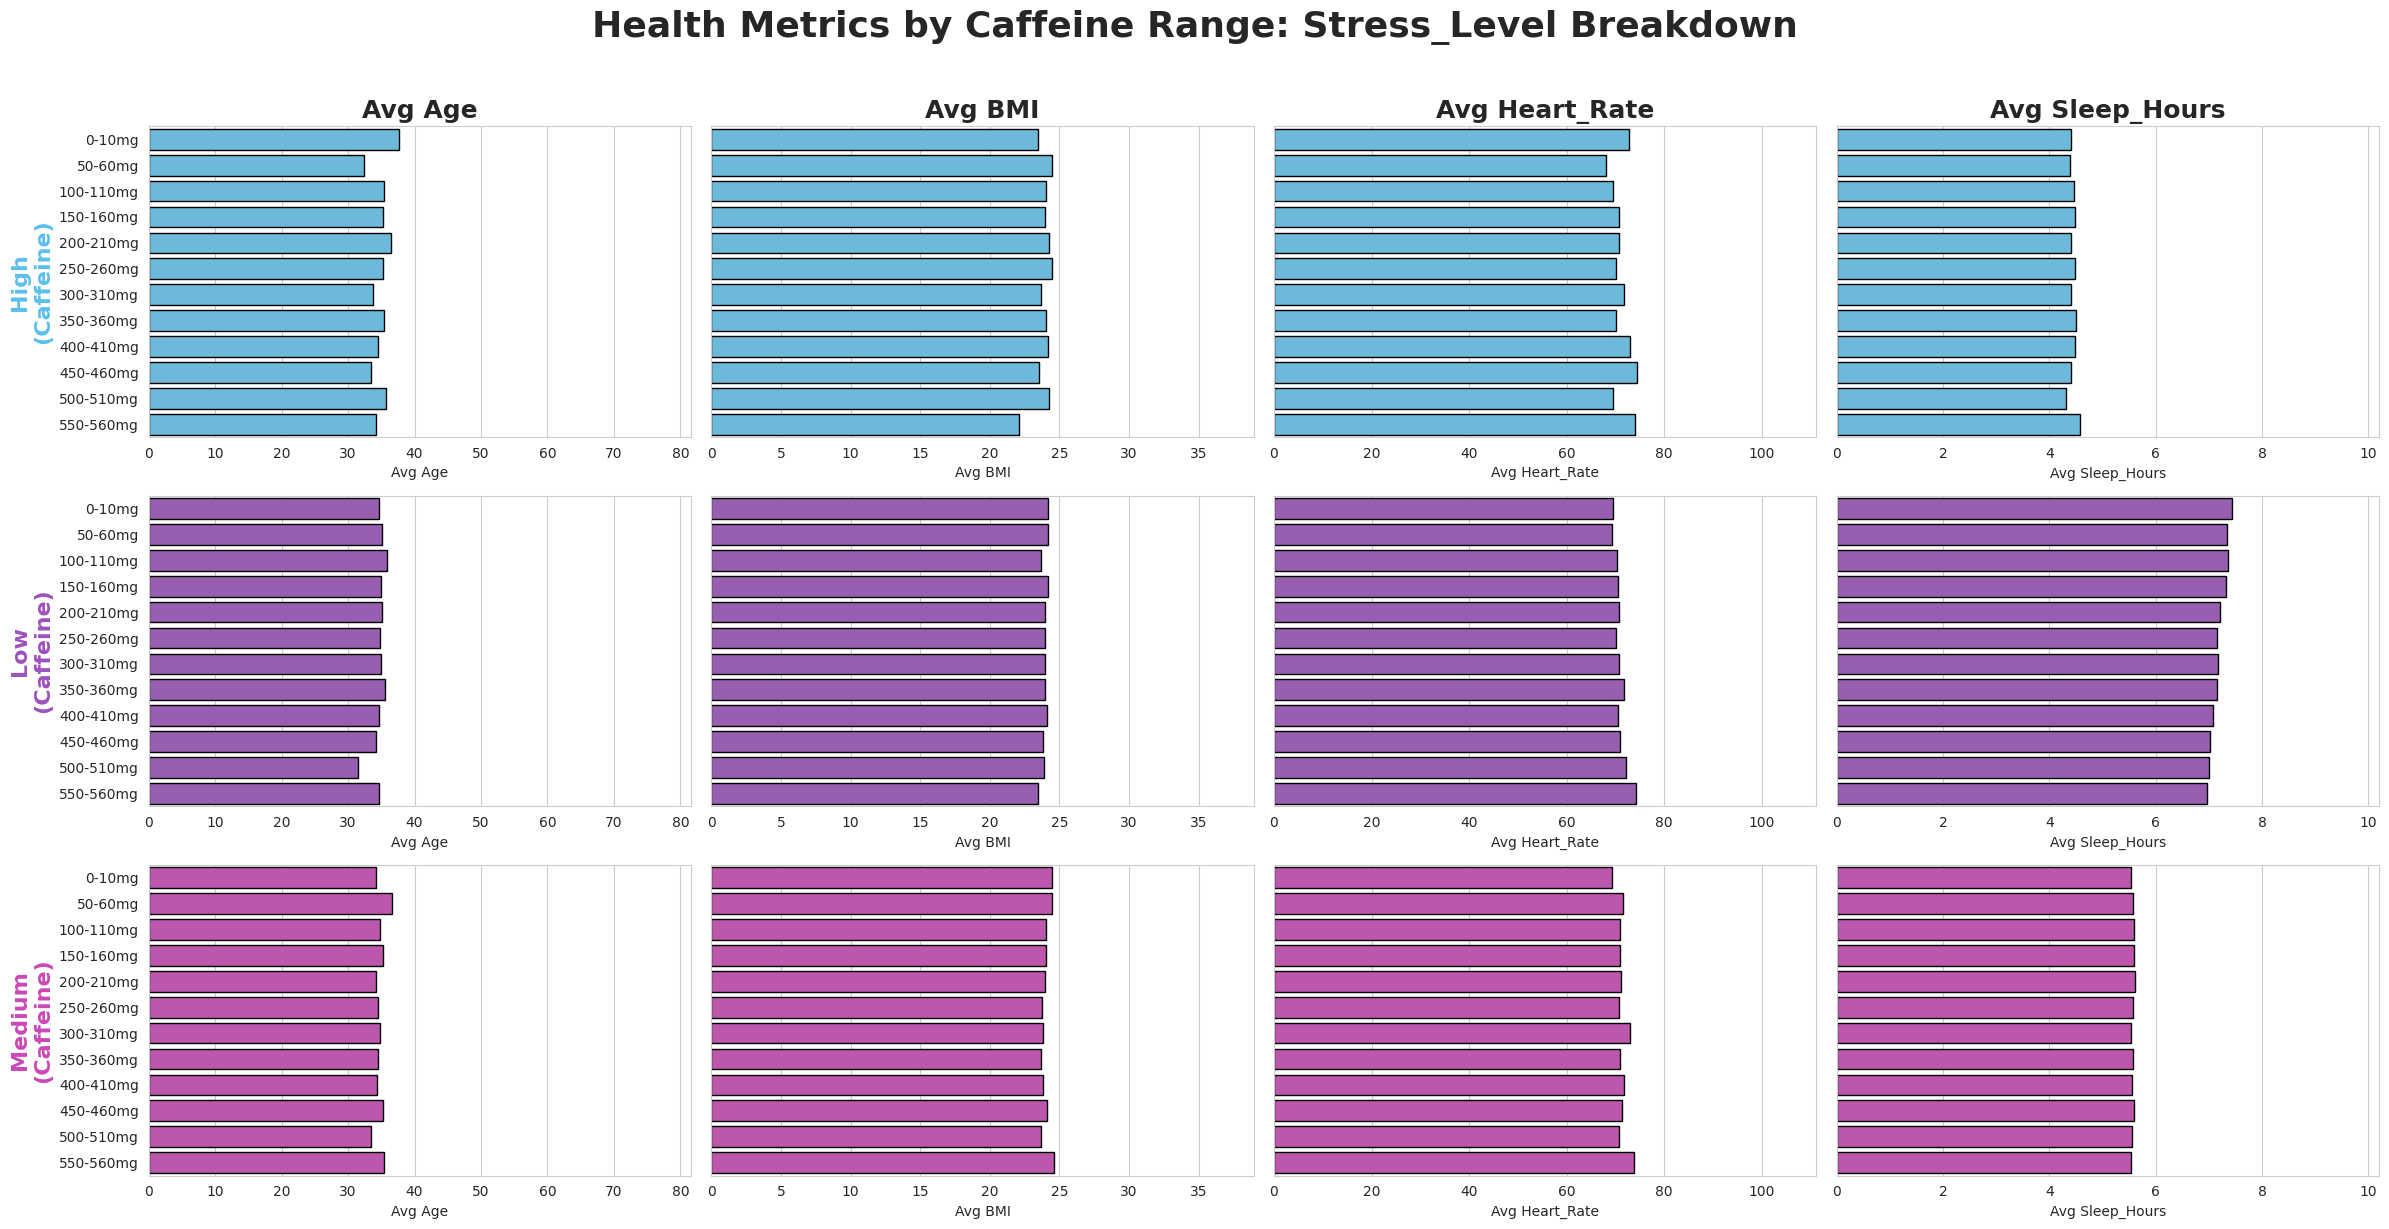

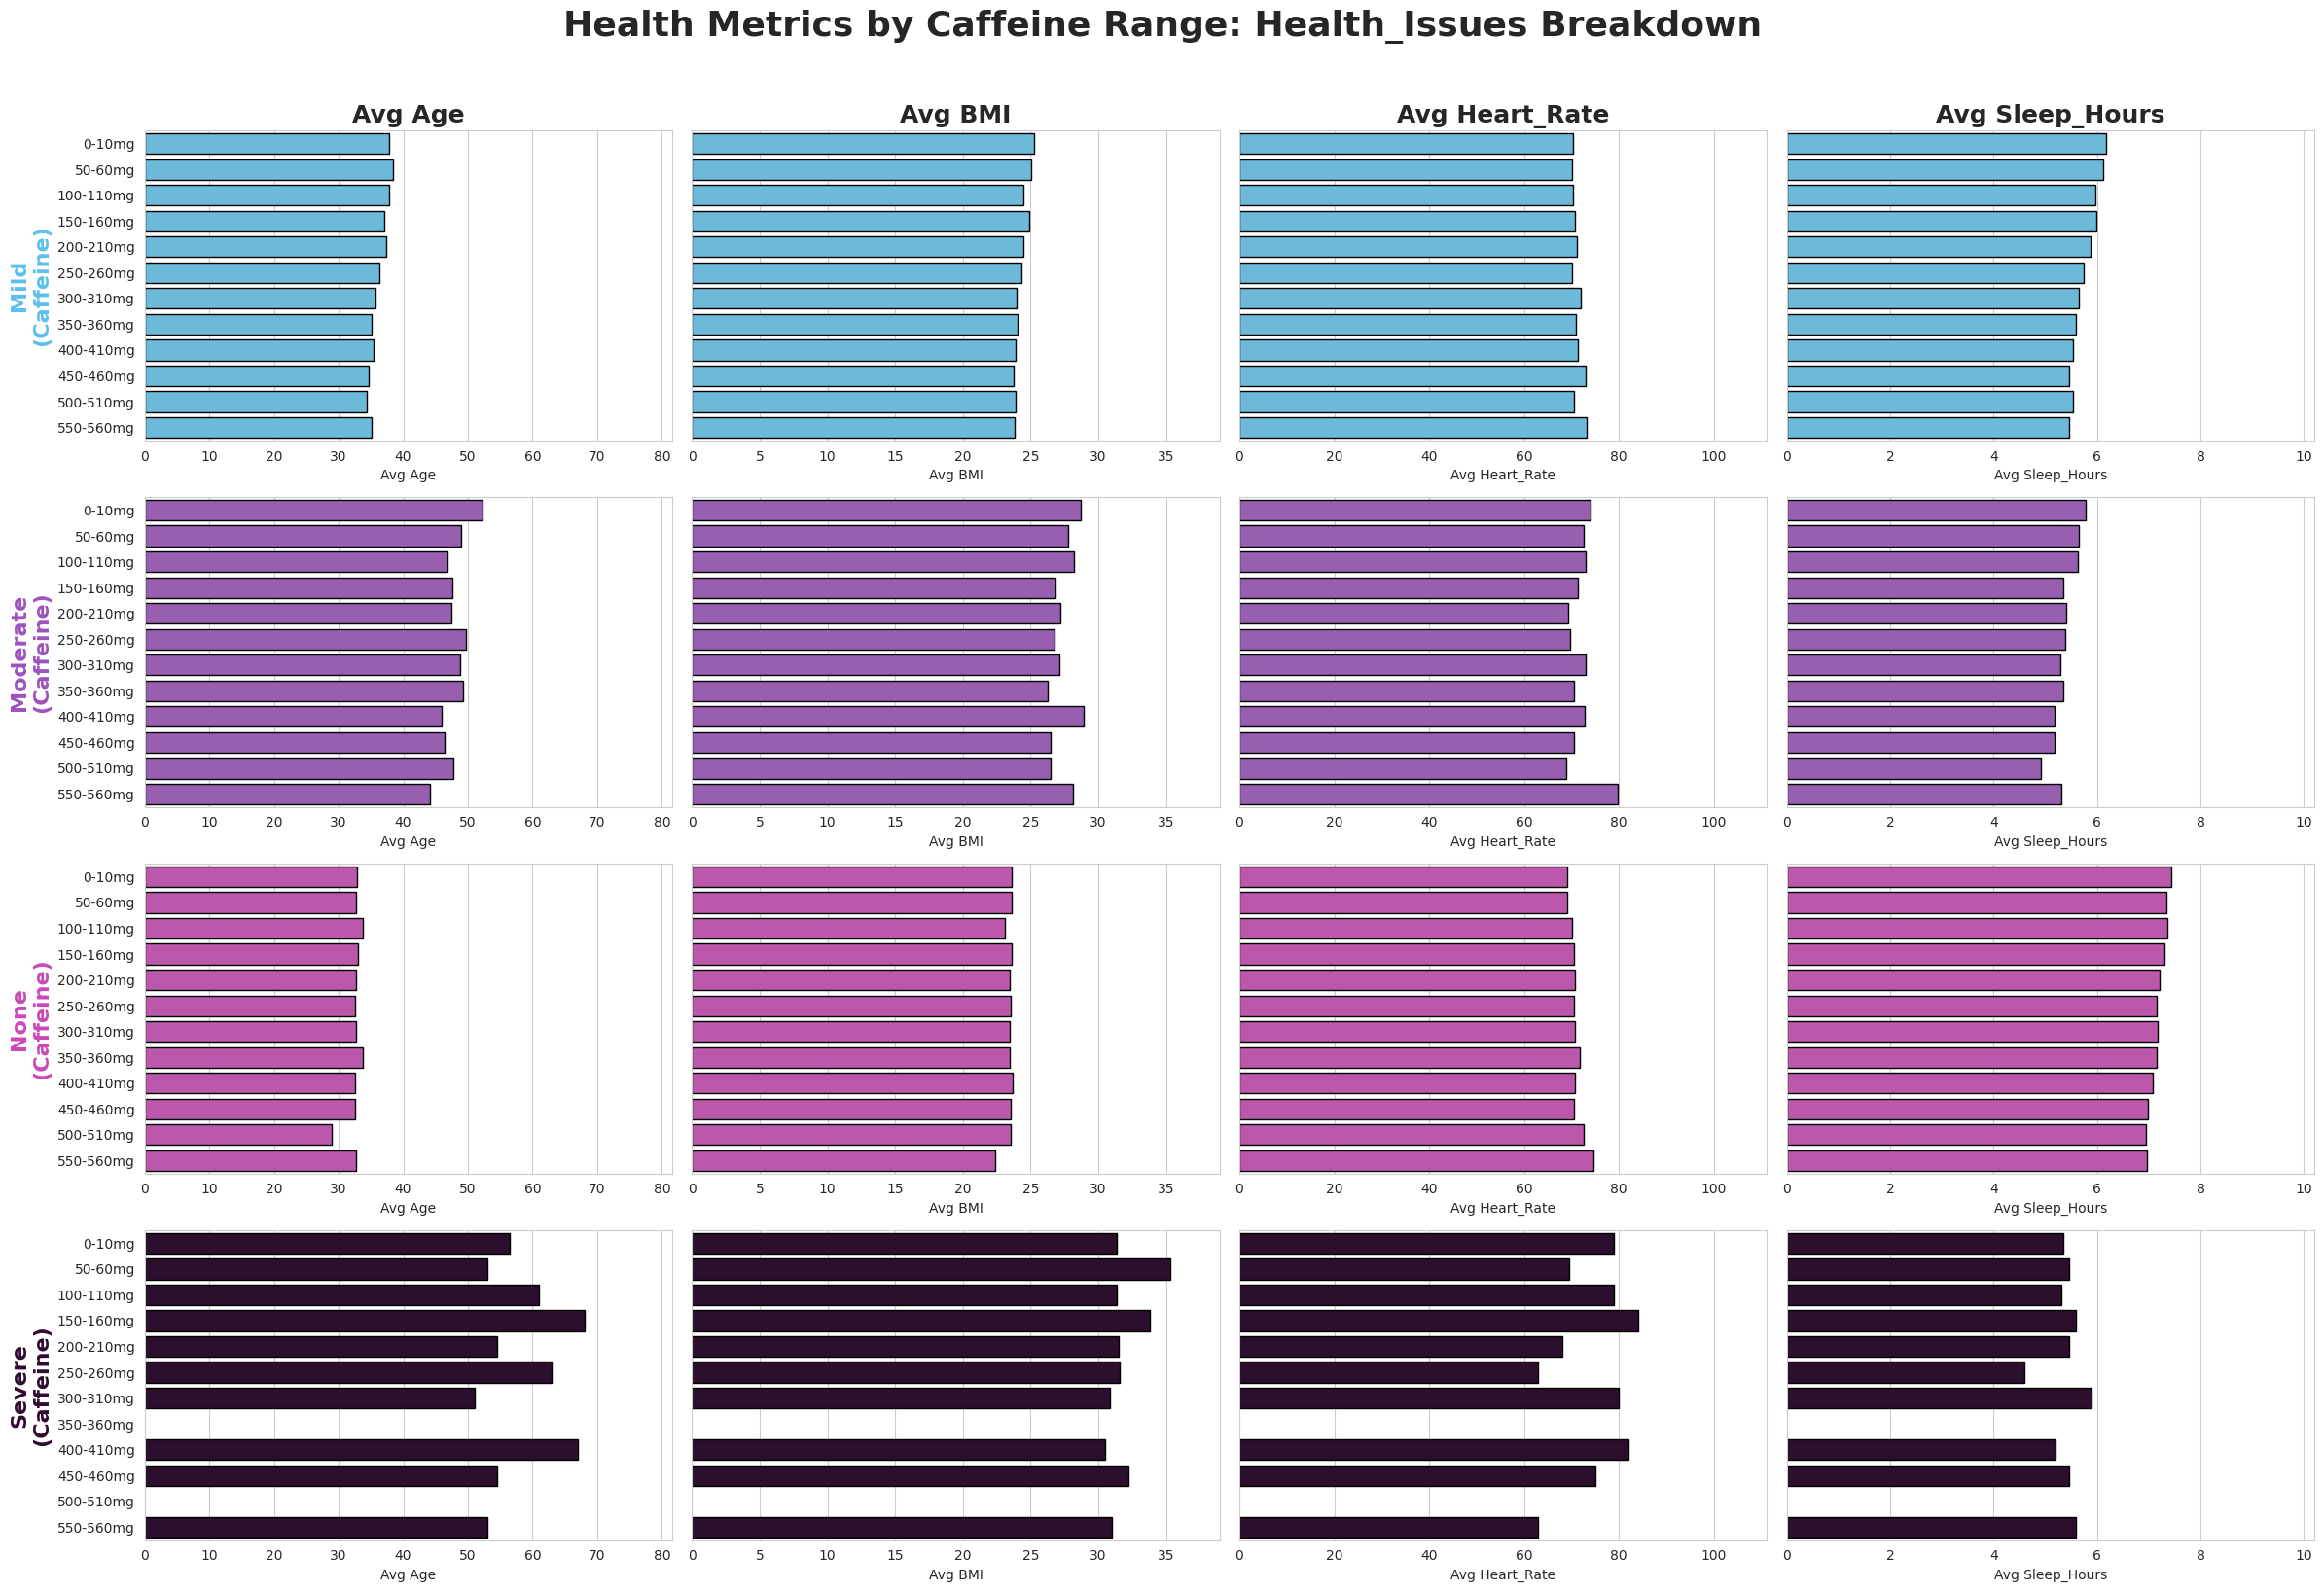

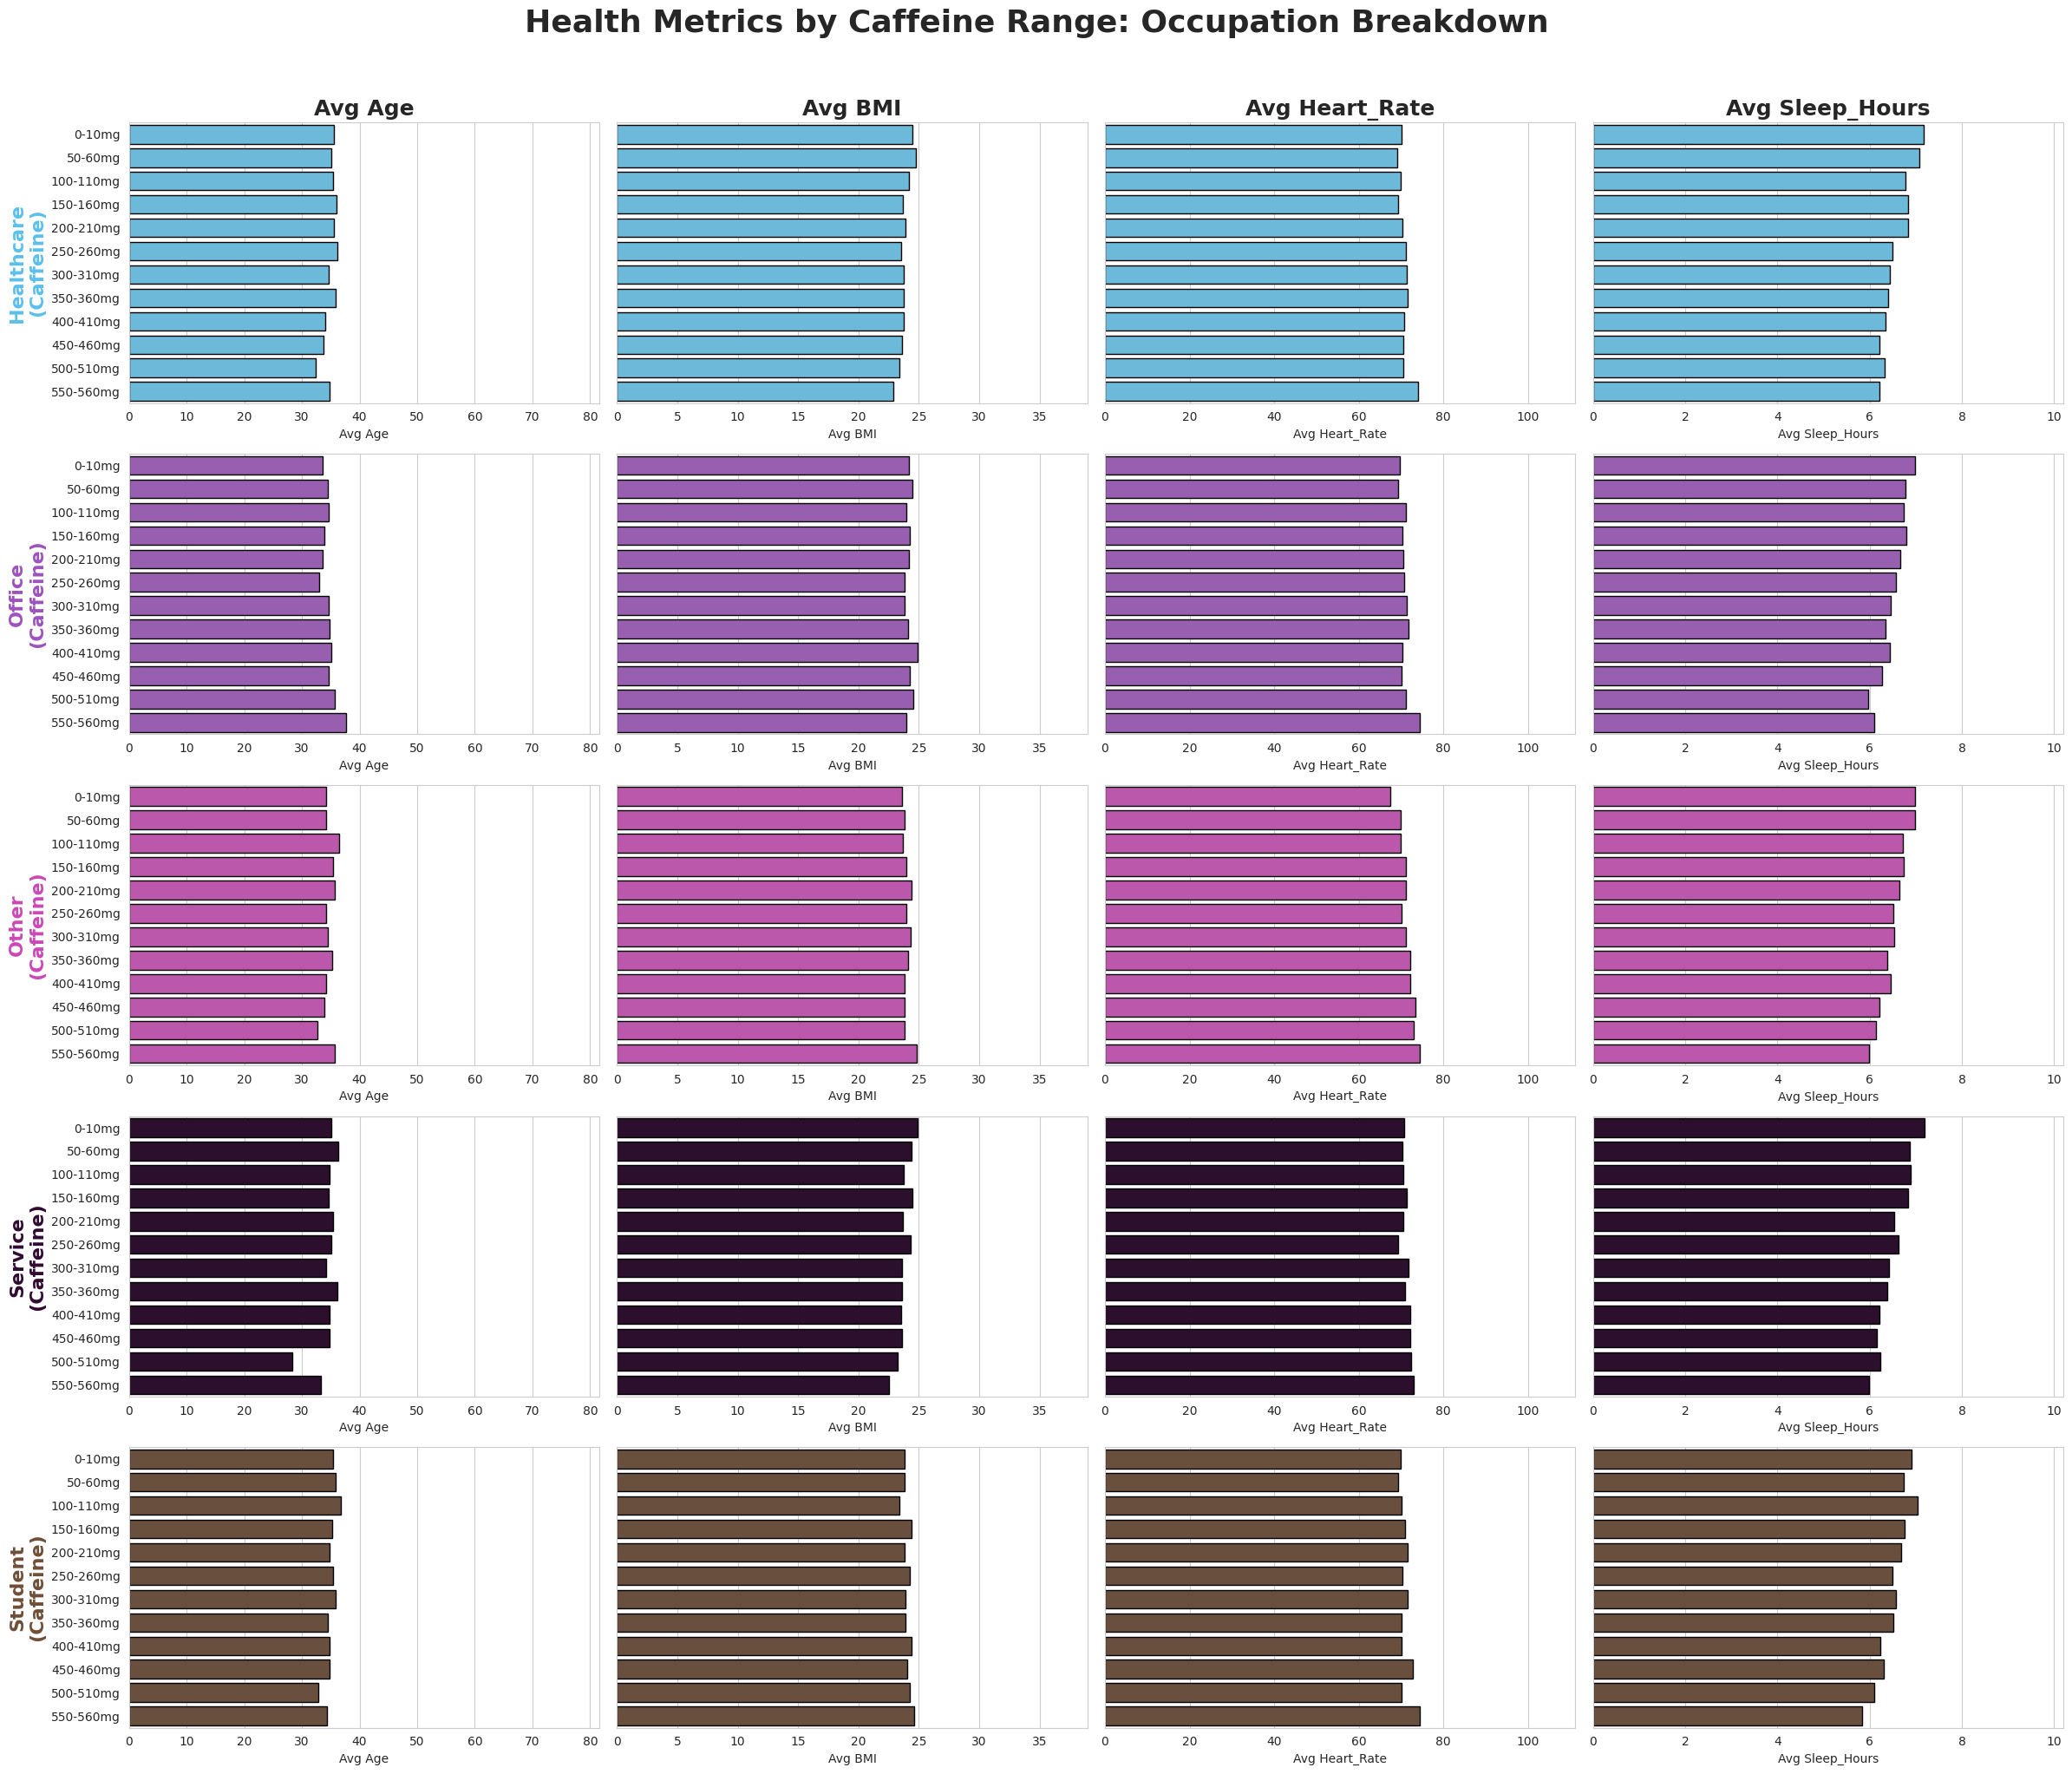

In [ ]:
# Cell 16: Faceted Caffeine Impact (Shared Scales + Row Titles)
# One Row per Category Value, with locked scales for fair comparison

# 1. Re-create Granular Bins
bins = range(0, 650, 50)
labels = [f'{i}-{i+10}mg' for i in bins[:-1]]
df['Caffeine_Range'] = pd.cut(df['Caffeine_mg'], bins=bins, labels=labels)

# 2. Setup Variables
multi_cats = ['Sleep_Quality', 'Stress_Level', 'Health_Issues', 'Occupation']
num_vars = ['Age', 'BMI', 'Heart_Rate', 'Sleep_Hours']

# 3. Loop through each Category
for cat in multi_cats:
    # Get unique values and sort them
    unique_vals = df[cat].dropna().unique()
    try:
        unique_vals = sorted(unique_vals)
    except:
        pass # Keep default order if sorting fails
        
    n_rows = len(unique_vals)
    n_cols = len(num_vars)
    
    # Create the Big Grid
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4 * n_rows))
    fig.suptitle(f'Health Metrics by Caffeine Range: {cat} Breakdown', fontsize=26, y=1.02, fontweight='bold')
    
    # Define colors for each group
    cat_palette = {val: custom_palette[i % len(custom_palette)] for i, val in enumerate(unique_vals)}

    for r, val in enumerate(unique_vals):
        for c, num in enumerate(num_vars):
            ax = axes[r, c] if n_rows > 1 else axes[c]
            
            # Filter Data
            subset = df[df[cat] == val]
            
            sns.barplot(
                data=subset,
                y='Caffeine_Range', 
                x=num, 
                orient='h',
                ax=ax,
                color=cat_palette[val],
                edgecolor='black',
                err_kws={'linewidth': 0}
            )
            
            # --- CRITICAL FIX 1: SHARED SCALES ---
            # We set the X-limit to the maximum value found in the WHOLE dataset for this variable.
            # We add 10% padding so the longest bar doesn't hit the edge.
            global_max = df[num].max() * 1.02
            ax.set_xlim(0, global_max)
            
            # --- CRITICAL FIX 2: ROW TITLES ---
            if c == 0:
                # Big bold label on the far left: "POOR SLEEP"
                ax.set_ylabel(f'{val}\n(Caffeine)', fontsize=16, fontweight='bold', color=cat_palette[val])
            else:
                ax.set_ylabel('')
                ax.set_yticklabels([]) # Hide caffeine labels on inner plots for cleaner look
            
            # Column Titles (Top Row Only)
            if r == 0:
                ax.set_title(f'Avg {num}', fontsize=18, fontweight='bold')
            
            ax.set_xlabel(f'Avg {num}')

    plt.tight_layout()
    plt.show()

# Clean up
df.drop(columns=['Caffeine_Range'], inplace=True)

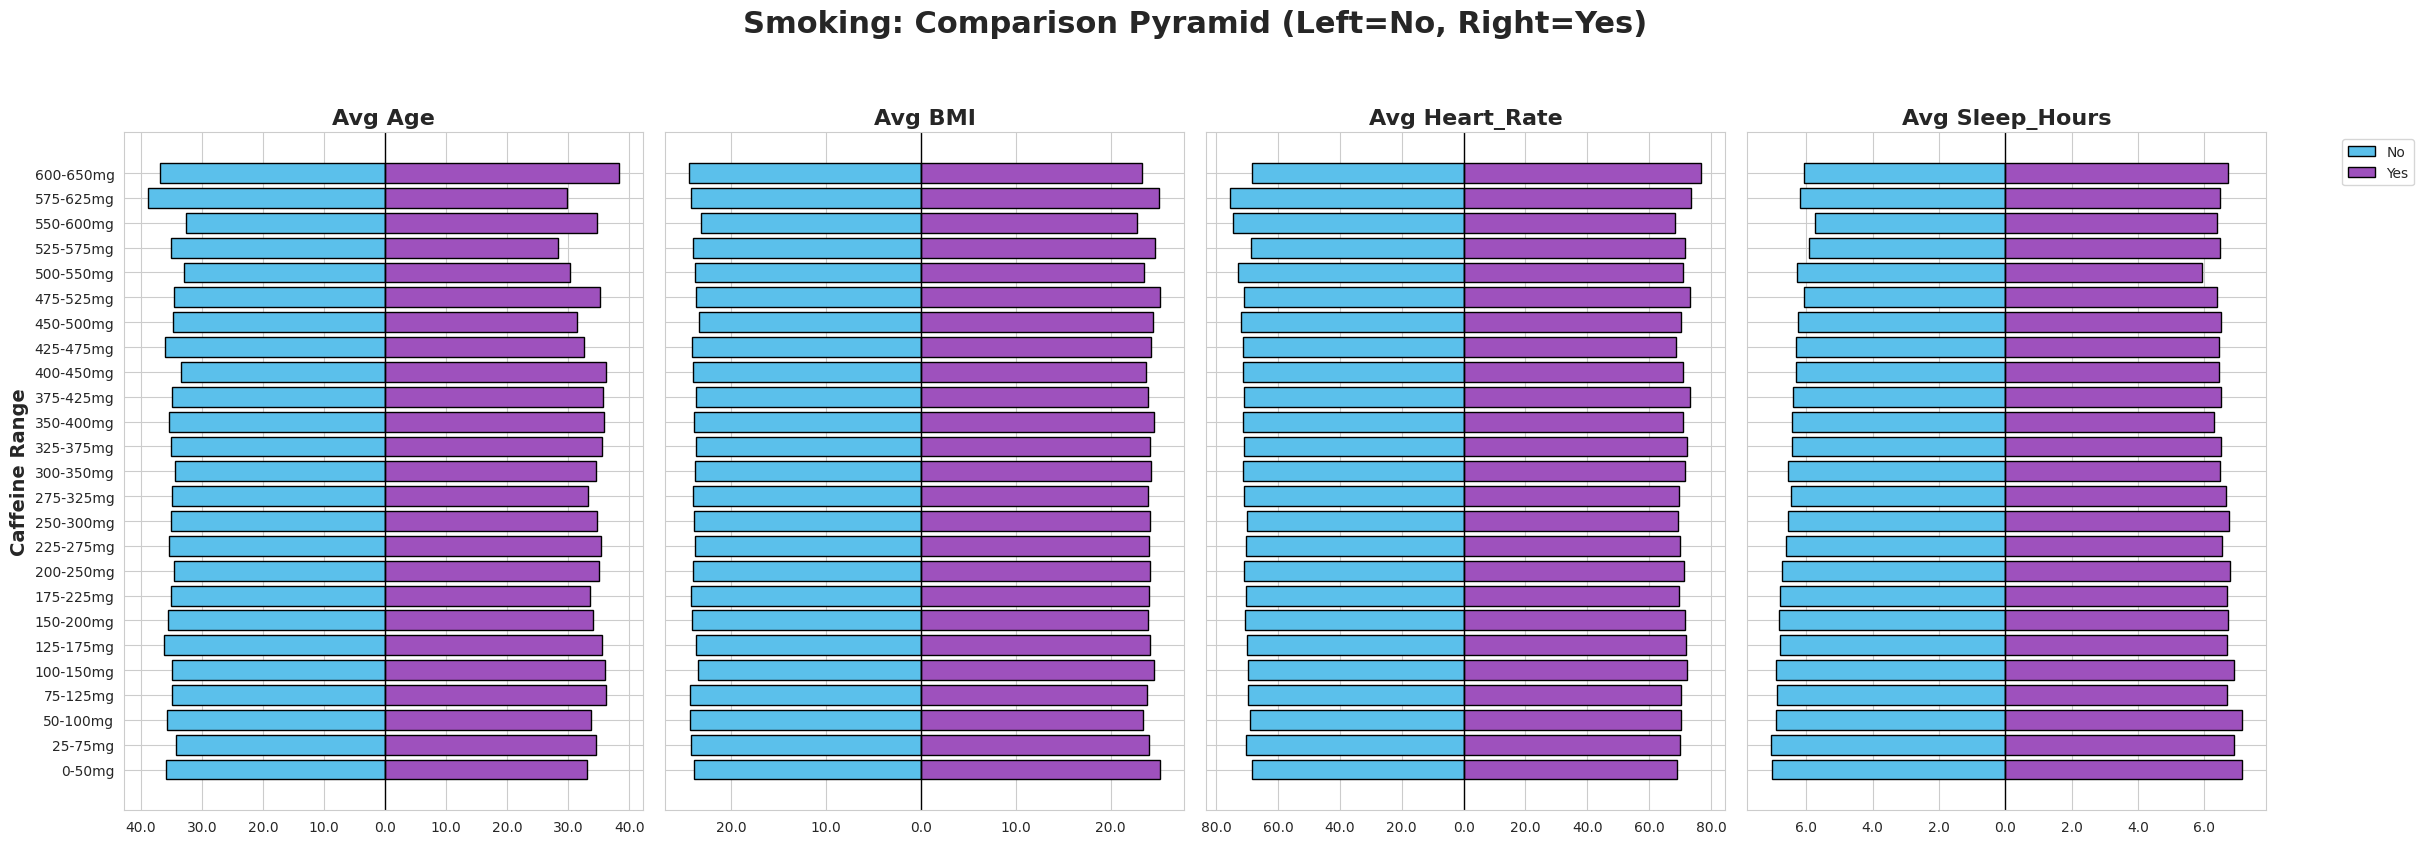

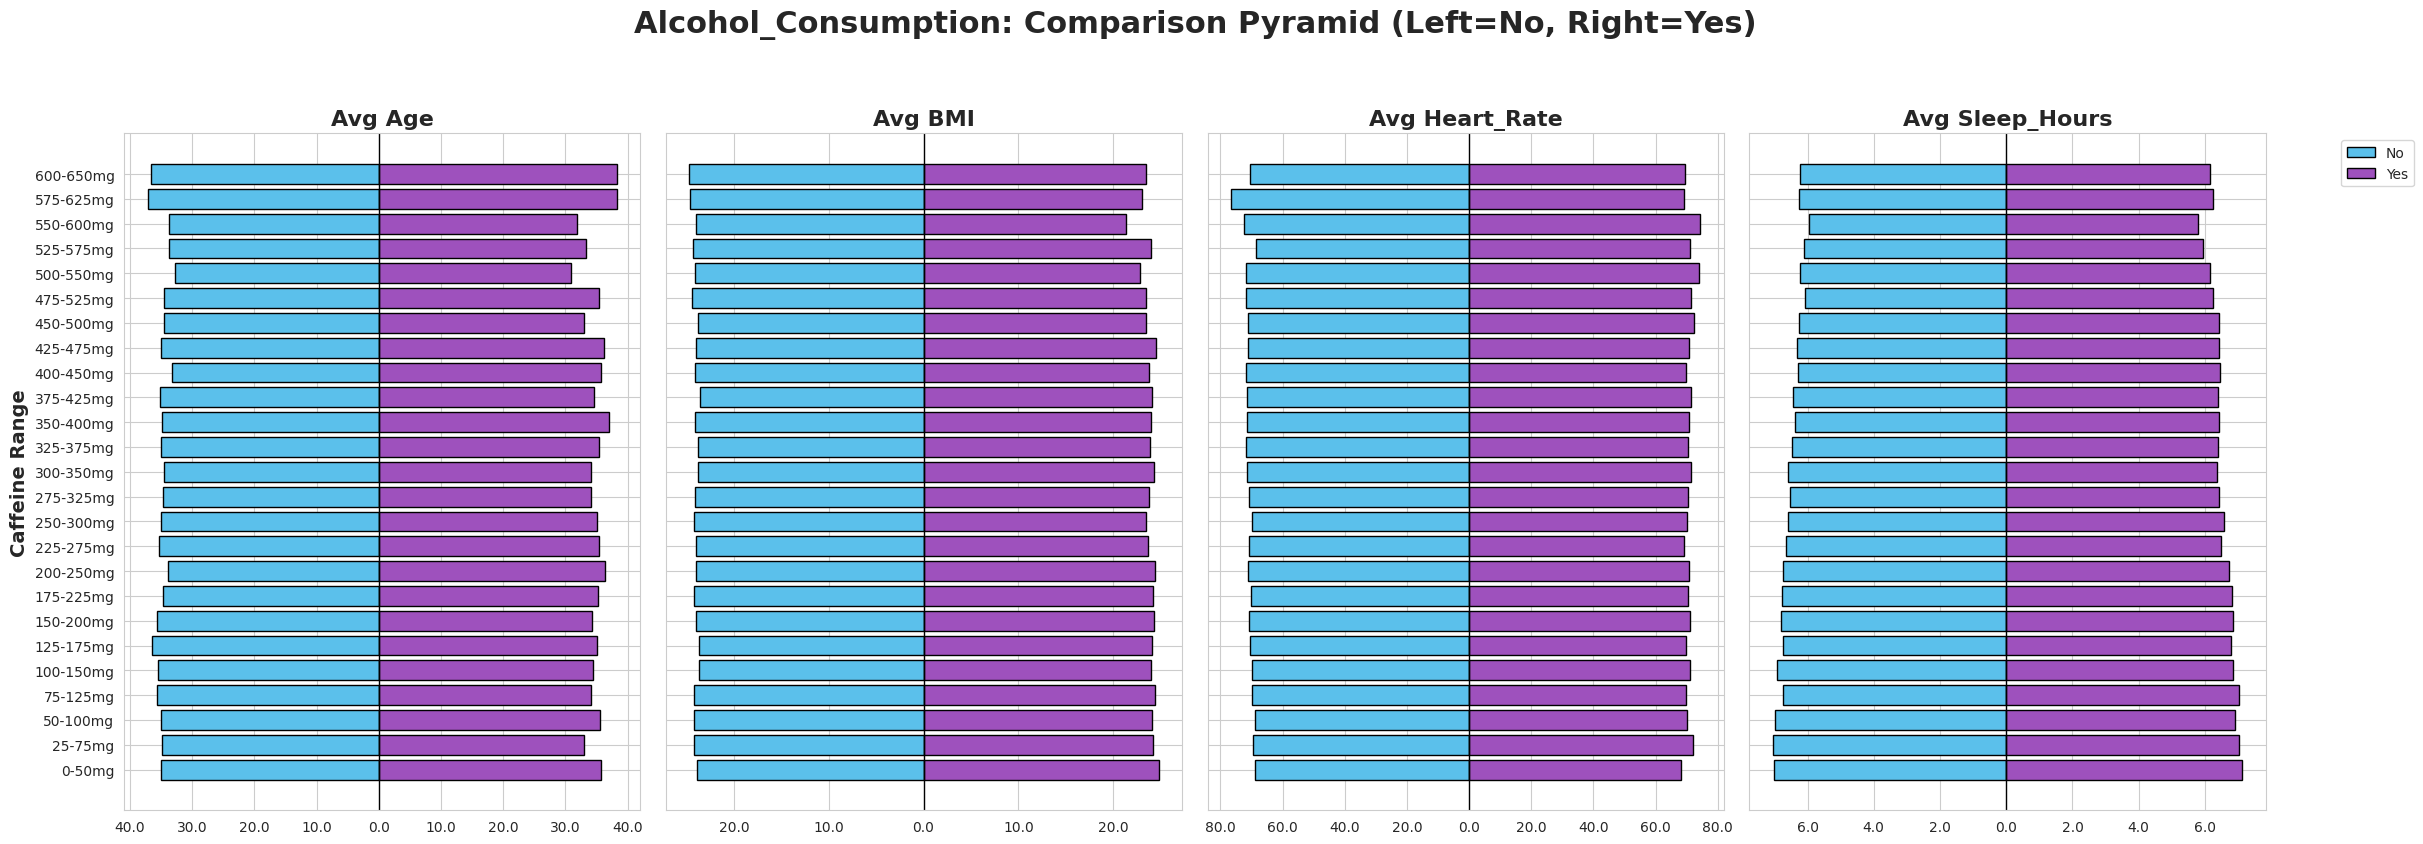

In [ ]:
# Cell 17: Binary "Tornado" Charts (Symmetric Side-by-Side)
# Left Side = "No" | Right Side = "Yes"
# Meeting in the middle at 0

# 1. Re-create Bins
bins = range(0, 650, 25)
labels = [f'{i}-{i+50}mg' for i in bins[:-1]]
df['Caffeine_Range'] = pd.cut(df['Caffeine_mg'], bins=bins, labels=labels)

# 2. Setup Variables
binary_cats = ['Smoking', 'Alcohol_Consumption']
num_vars = ['Age', 'BMI', 'Heart_Rate', 'Sleep_Hours']

# 3. Loop through Categories
for cat in binary_cats:
    # Get the "No" and "Yes" values sorted
    # Assuming 'No' is at index 0 and 'Yes' is at index 1
    unique_vals = sorted(df[cat].dropna().unique()) 
    val_no = unique_vals[0]  # e.g. 'No'
    val_yes = unique_vals[1] # e.g. 'Yes'
    
    # Create Grid
    fig, axes = plt.subplots(1, 4, figsize=(24, 8))
    fig.suptitle(f'{cat}: Comparison Pyramid (Left={val_no}, Right={val_yes})', fontsize=22, y=1.05, fontweight='bold')
    
    for i, num in enumerate(num_vars):
        ax = axes[i]
        
        # A. Calculate Averages
        # Group by Range + Category
        grouped = df.groupby(['Caffeine_Range', cat])[num].mean().unstack()
        
        # B. Plot "No" bars to the LEFT (Negative values)
        # We make them negative so they point left
        ax.barh(
            grouped.index, 
            -grouped[val_no], 
            color=custom_palette[0], # Blue/Teal
            edgecolor='black',
            height=0.8,
            label=val_no
        )
        
        # C. Plot "Yes" bars to the RIGHT (Positive values)
        ax.barh(
            grouped.index, 
            grouped[val_yes], 
            color=custom_palette[1], 
            edgecolor='black',
            height=0.8,
            label=val_yes
        )
        
        # D. Formatting the Axis
        ax.set_title(f'Avg {num}', fontsize=16, fontweight='bold')
        
        # Draw a line down the middle
        ax.axvline(0, color='black', linewidth=1)
        
        # Fix X-Axis Labels to be positive on both sides
        # Get current ticks (which include negatives)
        ticks = ax.get_xticks()
        # Make them all absolute values (remove the minus sign)
        ax.set_xticklabels([f'{abs(x):.1f}' for x in ticks])
        
        # Y-Axis Labels (Caffeine)
        if i == 0:
            ax.set_ylabel('Caffeine Range', fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel('')
            ax.set_yticklabels([]) # Hide labels for inner plots
            
        # Add Legend to the last plot only
        if i == 3:
            ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

    plt.tight_layout()
    plt.show()

# Clean up
df.drop(columns=['Caffeine_Range'], inplace=True)

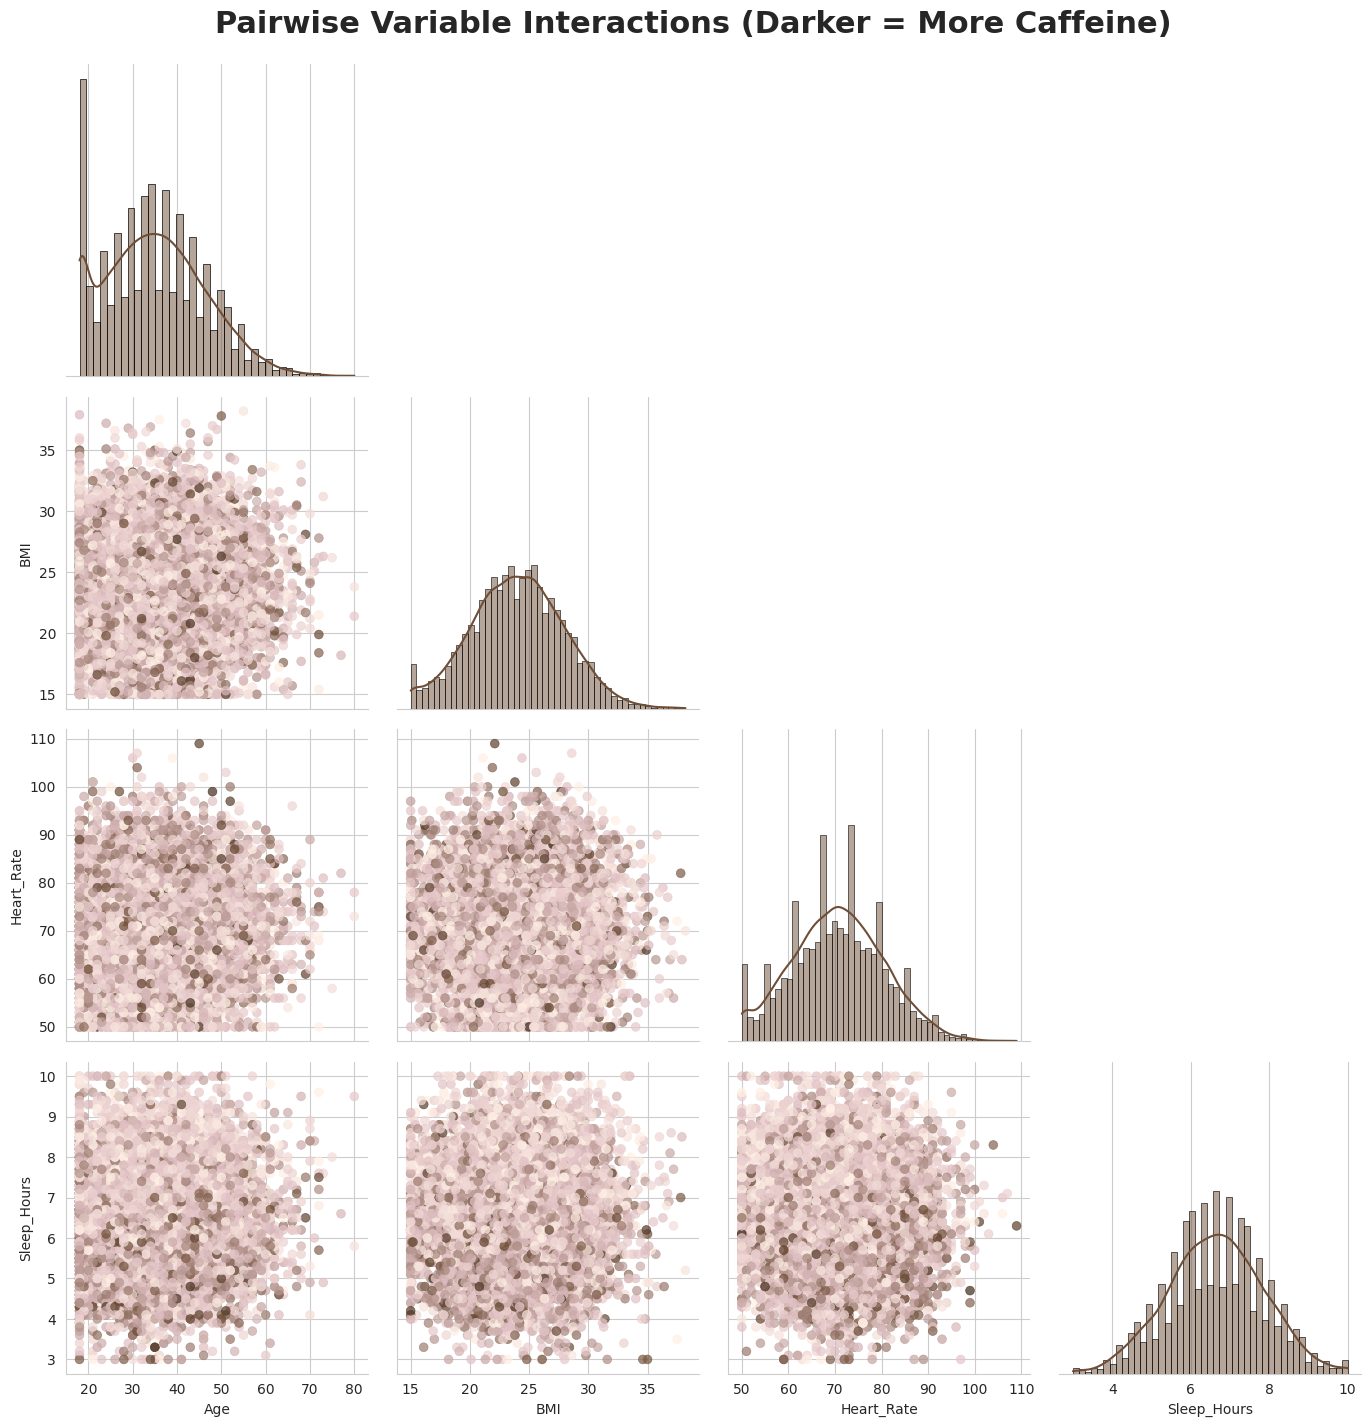

In [ ]:
# corner=True removes the duplicate mirrored plots on the top right
g = sns.PairGrid(df, vars=continuous_vars, corner=True, height=3.5)

# 4. Map the Lower Triangle to Scatter Plots
g.map_lower(
    sns.scatterplot, 
    hue=df['Caffeine_mg'],    # Color the dots by Caffeine
    palette=gradient, # Use the Latte -> Espresso gradient
    alpha=0.7,                # Slight transparency to see overlapping dots
    edgecolor=None,
    s=40                      # Dot size
)

# 5. Map the Diagonal to Histograms
# This shows the standalone distribution of the variable on that row/column
g.map_diag(
    sns.histplot, 
    color=coffee_color, 
    kde=True,
    edgecolor='black'
)

g.fig.suptitle('Pairwise Variable Interactions (Darker = More Caffeine)', fontsize=22, fontweight='bold', y=1.02)
plt.show()